# Feature Analysis Code

## Imports

In [1]:
import pandas as pd
import openpyxl
import scipy
import numpy as np
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneGroupOut, permutation_test_score, GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegressionCV
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor
from scipy.stats import pearsonr
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.feature_selection import VarianceThreshold
from sklearn import set_config
import os
from collections import defaultdict
import seaborn as sns



## Read Extracted Data

In [2]:
features_df = pd.read_csv("extracted_features/extracted_features.csv")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
n_participants = len(features_df) // 3
participants_df = features_df.iloc[:n_participants]

features_df.loc[:2]

,participant_id,age,gender,handedness,val_baseline,ar_baseline,round,emotion,emotion_name,erased_pixels,drawing_time,val_start,ar_start,val_end,ar_end,n_strokes,n_undone_strokes,n_eraser_strokes,stroke_total_length,stroke_mean_length,stroke_std_length,stroke_mean_speed,stroke_std_speed,stroke_mean_accel,stroke_std_accel,stroke_mean_pressure,stroke_std_pressure,stroke_pressure_slope,pen_size_used_count,pen_size_mean,pen_size_std,stroke_mean_curvature,stroke_mean_angularity,avg_time_between_strokes,std_time_between_strokes,total_pause_time,pause_ratio,stroke_frequency,stroke_mean_abs_jerk,stroke_speed_zero_cross_rate,pressure_velocity_corr,tilt_x_mean,tilt_y_mean,tilt_x_std,tilt_y_std,tilt_pressure_corr,stroke_mean_straightness,stroke_std_straightness,bbox_width,bbox_height,bbox_area,centroid_x,centroid_y,spatial_spread,ink_density,speed_dominant_freq,speed_dominant_freq_power,stroke_speed_trend,stroke_speed_half_diff,stroke_length_trend,stroke_length_half_diff,pressure_change_bandwidth,pressure_change_median_freq,pressure_change_peaks_per_sec,pressure_change_distance_to_mean,tiltx_change_bandwidth,tiltx_change_median_freq,tiltx_change_peaks_per_sec,tiltx_change_distance_to_mean,tilty_change_bandwidth,tilty_change_median_freq,tilty_change_peaks_per_sec,tilty_change_distance_to_mean,speed_peaks_per_sec,speed_distance_to_mean,trajectory_fractal_dimension,tilt_magnitude_mean,tilt_magnitude_std,tilt_angle_mean,tiltx_trend,tilty_trend,stroke_straightness_trend,bbox_aspect_ratio,bbox_diagonal,bbox_elongation
0,kadd,22,2,2,0.230392,-0.630719,1,1,EXCITEMENT,2925,300.144187,0.519608,0.212418,0.189542,-0.209150,84,1,0,258.891932,3.045787,4.848980,962.544641,511.016062,6.948090e+06,3.442235e+06,0.306292,0.095398,0.000642,2,5.235294,2.156506,0.457213,20.097923,2.565984,7.066338,215.542618,0.718130,0.279865,9.781474e+11,113.565581,0.085469,0.297498,0.010090,0.012162,0.015106,-0.016214,0.732474,0.259776,29.121526,14.645106,426.487845,15.554351,4.848695,9.328029,0.607032,0.030325,0.043924,-5.767422,-344.849517,0.007509,-0.392597,15.545423,8.585804,6.554020,0.014320,15.488563,8.544107,1.758858,0.014150,15.803186,8.585804,2.198572,0.015667,7.467565,0.049265,1.409245,0.315707,0.011969,-0.016987,-3.044864e-03,-0.001624,-0.001436,1.988482,32.596663,0.330764
1,onxu,24,2,2,0.638889,0.183007,1,2,CONTENTMENT,17127,280.178477,-0.014706,-0.328431,0.290850,-0.560458,136,0,15,195.543128,1.294988,3.167279,476.008228,228.155519,5.432016e+06,2.095325e+06,0.400103,0.136897,-0.000224,2,8.476821,10.469024,0.546502,28.395087,1.339639,1.612450,200.945883,0.717207,0.538942,4.379500e+11,67.157593,0.041145,0.711885,-0.010781,0.006843,0.008506,0.092302,0.728803,0.299328,15.319855,10.443264,159.989294,9.197093,6.847818,4.521808,1.222226,0.022943,0.043746,-1.470417,-130.641889,-0.017692,-1.408091,15.134574,8.224979,5.513910,0.014118,15.176636,8.599711,1.085957,0.014293,15.581958,8.569121,2.248390,0.014688,6.852238,0.039864,1.267295,0.714070,0.006809,-0.014881,9.426996e-07,-0.000091,0.000835,1.466960,18.540758,0.189286
2,hnba,23,2,1,1.000000,0.661765,1,3,ANGER,52003,182.022784,1.000000,0.576797,0.594771,0.441176,75,21,0,190.614823,1.985571,4.198126,1302.869696,703.577493,9.989735e+06,4.706550e+06,0.480846,0.121747,-0.000018,1,5.000000,0.000000,0.396357,13.122999,1.441679,2.975182,136.959527,0.752431,0.412036,1.219003e+12,316.636125,0.190377,-0.252473,-0.027237,0.006792,0.005068,0.051451,0.760671,0.291108,29.428230,10.259242,301.911332,12.852581,9.211173,8.506372,0.631360,0.025443,0.055745,-9.791789,-410.936180,-0.043483,-1.628896,12.473453,6.806015,5.025002,0.030475,13.033201,6.965034,1.494779,0.034560,12.479814,6.933230,1.157659,0.031774,5.686521,0.113759,1.219221,0.263167,0.007232,-3.004710,1.518448e-03,-0.000232,-0.004105,2.868460,31.165249,0.482998


In [3]:
EMOTION_TO_3WAY = {
    "EXCITEMENT":  "positive",
    "CONTENTMENT": "positive",
    "ANGER":       "negative",
    "SADNESS":     "negative",
    "NEUTRAL":     "neutral",
}

EMOTION_TO_AROUSAL = {
    "EXCITEMENT":  "high",
    "CONTENTMENT": "low",
    "ANGER":       "high",
    "SADNESS":     "low",
    "NEUTRAL":     "neutral",
}

features_df['emotion_3_way'] = features_df['emotion_name'].map(EMOTION_TO_3WAY)
features_df['emotion_3_way_arousal'] = features_df['emotion_name'].map(EMOTION_TO_AROUSAL)

## Some Statistics

### Mood Measurement Results

In [ ]:
def show_scatter(df):
    colors = ['orange', 'forestgreen', 'lightgrey', 'red', 'cornflowerblue', 'lightgrey']
    emotions = ['EXCITEMENT', 'CONTENTMENT', 'NEUTRAL', 'ANGER', 'SADNESS']
    markers = ['o', 's', 'X', '^', 'D']
    
    # plt.figure()
    # for emotion,color,m in zip(emotions, colors, markers):
    #     emo_df = df[df['emotion_name'] == emotion]
    #     val_emo = emo_df['val_start']
    #     ar_emo = emo_df['ar_start']
        
    #     val_mean = np.mean(emo_df['val_start'])
    #     ar_mean = np.mean(emo_df['ar_start'])
    #     val_std = np.std(emo_df['val_start'])
    #     ar_std = np.std(emo_df['ar_start'])
    #     print(f"{emotion}\n\tValence:\tmean: {val_mean}\tstd: {val_std}\n\tArousal:\tmean: {ar_mean}\tstd: {ar_std}")
    #     plt.scatter(val_emo, ar_emo, alpha=0.7, color=color, marker=m, label=emotion.lower())
    # plt.xlabel(f"valence")
    # plt.ylabel(f"arousal")
    # plt.plot([-1, 1], [0, 0], linestyle='--', color='grey', alpha=0.5)
    # plt.plot([0,0], [-1, 1], linestyle='--', color='grey', alpha=0.5)
    # plt.legend()
    # # plt.xlim((-1, 1))
    # # plt.ylim((-1, 1))
    # plt.title("raw arousal/valence values before drawing")
    # plt.savefig("figures/val_ar_before_drawing.pdf", bbox_inches="tight")
    # plt.show()
    
    # plt.figure()
    # for emotion,color,m in zip(emotions, colors, markers):
    #     emo_df = df[df['emotion_name'] == emotion]
    #     val_emo = emo_df['val_end']
    #     ar_emo = emo_df['ar_end']
    #     plt.scatter(val_emo, ar_emo, alpha=0.7, color=color, marker=m, label=emotion.lower())
    # plt.xlabel(f"valence")
    # plt.ylabel(f"arousal")
    # plt.legend()
    # # plt.xlim((-1, 1))
    # # plt.ylim((-1, 1))
    # plt.title("raw arousal/valence values after drawing")
    # plt.plot([-1, 1], [0, 0], linestyle='--', color='grey', alpha=0.5)
    # plt.plot([0,0], [-1, 1], linestyle='--', color='grey', alpha=0.5)
    # plt.savefig("figures/val_ar_after_drawing.pdf", bbox_inches="tight")
    # plt.show()
    
    # plt.figure()
    # for emotion,color,m in zip(emotions, colors, markers):
    #     emo_df = df[df['emotion_name'] == emotion]
    #     val_emo = emo_df['val_start'] - emo_df['val_baseline']
    #     ar_emo = emo_df['ar_start'] - emo_df['ar_baseline']
    #     plt.scatter(val_emo, ar_emo, alpha=0.7, color=color, marker=m, label=emotion.lower())
    # plt.xlabel(f"valence")
    # plt.ylabel(f"arousal")
    # plt.xlim((-2, 2))
    # plt.ylim((-2, 2))
    # plt.legend()
    # plt.title("valence/arousal difference to baseline")
    # plt.plot([-2, 2], [0, 0], linestyle='--', color='grey', alpha=0.5)
    # plt.plot([0,0], [-2, 2], linestyle='--', color='grey', alpha=0.5)
    # plt.savefig("figures/val_ar_to_baseline.pdf", bbox_inches="tight")
    # plt.show()
    
    # plt.figure()
    # for emotion,color,m in zip(emotions, colors, markers):
    #     emo_df = df[df['emotion_name'] == emotion]
    #     val_emo = emo_df['val_end'] - emo_df['val_start']
    #     ar_emo = emo_df['ar_end'] - emo_df['ar_start']
    #     plt.scatter(val_emo, ar_emo, alpha=0.7, color=color, marker=m, label=emotion.lower())
    # plt.xlabel(f"valence")
    # plt.ylabel(f"arousal")
    # plt.legend()
    # plt.xlim((-2, 2))
    # plt.ylim((-2, 2))
    # plt.plot([-2, 2], [0, 0], linestyle='--', color='grey', alpha=0.5)
    # plt.plot([0,0], [-2, 2], linestyle='--', color='grey', alpha=0.5)
    # plt.title("valence/arousal change while drawing")
    # plt.savefig("figures/val_ar_change_during_drawing.pdf", bbox_inches="tight")
    # plt.show()

    plt.figure()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Valence
    valence_data = [
        df[df['emotion_name'] == emotion]['val_start'].dropna()
        for emotion in emotions
    ] + [df['val_baseline']]
    
    bp_val = axes[0].boxplot(
        valence_data,
        positions=range(len(emotions)),
        patch_artist=True,
        showmeans=False,
    )
    for median in bp_val['medians']:
        median.set_color('black')
    axes[0].set_xticks(range(len(emotions)))
    axes[0].set_xticklabels([emotion.lower() for emotion in emotions] + ["baseline"])
    axes[0].set_xlabel("emotion")
    axes[0].set_ylabel("valence")
    axes[0].set_ylim((-1.1, 1.1))
    axes[0].set_title("Valence distributions")
    for box, color in zip(bp_val['boxes'], colors):
        box.set_facecolor(color)
        box.set_alpha(0.7)
        
    # Arousal
    arousal_data = [
        df[df['emotion_name'] == emotion]['ar_start'].dropna()
        for emotion in emotions
    ] + [df['val_baseline']]
    
    bp_ar = axes[1].boxplot(
        arousal_data,
        positions=range(len(emotions)),
        patch_artist=True,
        showmeans=False
    )
    for median in bp_ar['medians']:
        median.set_color('black')
    
    axes[1].set_xticks(range(len(emotions)))
    axes[1].set_xticklabels([emotion.lower() for emotion in emotions])
    axes[1].set_xlabel("emotion")
    axes[1].set_ylabel("arousal")
    axes[1].set_ylim((-1.1, 1.1))
    axes[1].set_title("Arousal distributions")
    for box, color in zip(bp_ar['boxes'], colors):
        box.set_facecolor(color)
        box.set_alpha(0.7)
        
    axes[0].axhline(
        y=0,
        linestyle='--',
        color='grey',
        alpha=0.5,
        zorder=0
    )
    axes[1].axhline(
        y=0,
        linestyle='--',
        color='grey',
        alpha=0.5,
        zorder=0
    )
    
    plt.tight_layout()
    plt.savefig("figures/val_ar_violin.pdf", bbox_inches="tight")
    plt.show()

<Figure size 640x480 with 0 Axes>

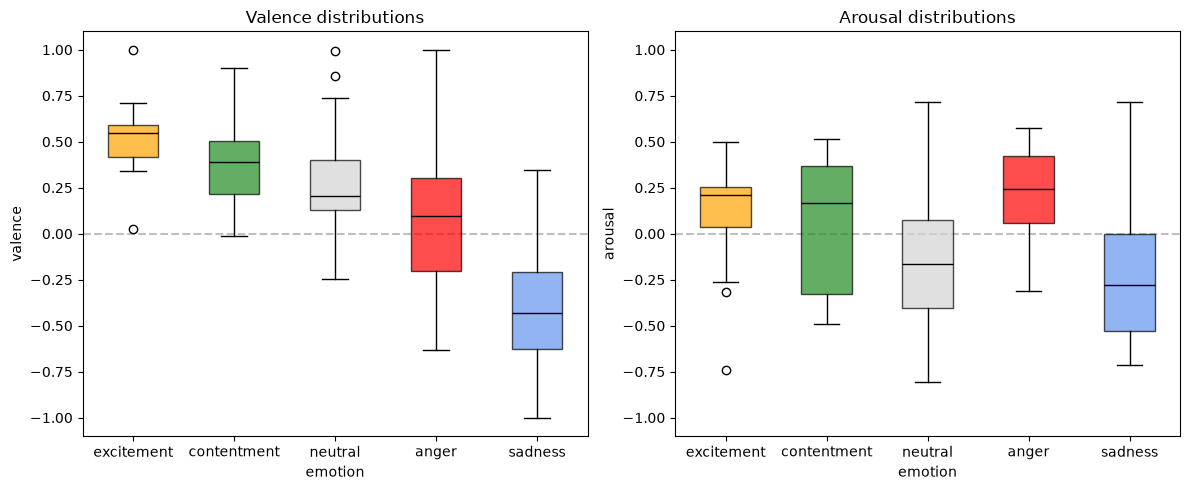

In [60]:
show_scatter(features_df)

### Average Mood Values

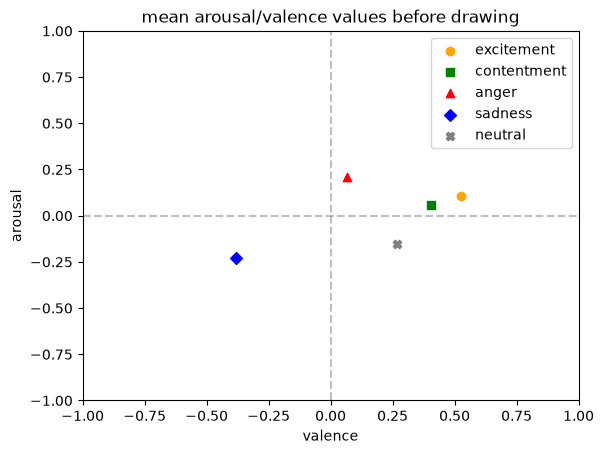

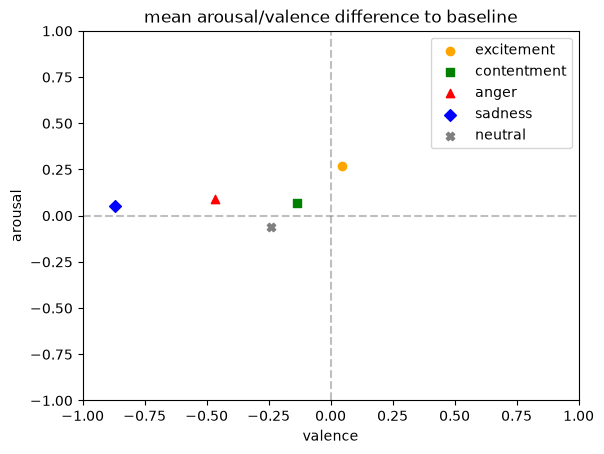

In [7]:
valence = [ 0.527, 0.405, 0.066, -0.383, 0.268]
arousal = [0.109, 0.059, 0.209, -0.227, -0.151]
color = ['orange', 'green', 'red', 'blue', 'grey']
emotion = [s.lower() for s in ['EXCITEMENT', 'CONTENTMENT', 'ANGER', 'SADNESS', 'NEUTRAL']]
markers = ['o', 's', '^', 'D', 'X']

for v,a,c,e,m in zip(valence, arousal, color, emotion, markers):
    plt.scatter(v, a, color=c, label=e, marker=m)
plt.xlabel(f"valence")
plt.ylabel(f"arousal")
plt.xlim((-1, 1))
plt.ylim((-1, 1))
plt.plot([-1, 1], [0, 0], linestyle='--', color='grey', alpha=0.5)
plt.plot([0,0], [-1, 1], linestyle='--', color='grey', alpha=0.5)
plt.legend()
plt.title("mean arousal/valence values before drawing")
plt.savefig("figures/val_ar_mean.pdf", bbox_inches="tight")
plt.show()
 
valence = [0.047, -0.137, -0.466, -0.871, -0.242,] 
arousal = [0.270, 0.069, 0.092, 0.052, -0.062,]

for v,a,c,e,m in zip(valence, arousal, color, emotion, markers):
    plt.scatter(v, a, color=c, label=e, marker=m)
plt.xlabel(f"valence")
plt.xlim((-1, 1))
plt.ylabel(f"arousal")
plt.ylim((-1, 1))
plt.plot([-1, 1], [0, 0], linestyle='--', color='grey', alpha=0.5)
plt.plot([0,0], [-1, 1], linestyle='--', color='grey', alpha=0.5)
plt.legend()
plt.title("mean arousal/valence difference to baseline")
plt.savefig("figures/val_ar_mean_difference.pdf", bbox_inches="tight")
plt.show()


### Gender Ratio

In [6]:
gender_percent = participants_df["gender"].value_counts(normalize=True) * 100

print(gender_percent)


gender
2    76.0
1    24.0
Name: proportion, dtype: float64


### Average Age

In [5]:
age_mean = participants_df["age"].mean()
age_std = participants_df["age"].std()
age_min = participants_df["age"].min()
age_max = participants_df["age"].max()

print(f"Mean age = {age_mean:.2f}")
print(f"SD age = {age_std:.2f}")
print(f"Range = {age_min}-{age_max}")


Mean age = 23.20
SD age = 2.74
Range = 19-33


### Inter Class Correlation

Calculates ratio of Between Subject and Within Subject Variance

In [5]:
def compute_variance_decomposition(df, feature_cols, id_col="participant_id"):
    """
    Decomposes each feature's total variance into between-participant
    and within-participant components (one-way random-effects ANOVA
    decomposition), and computes the Intraclass Correlation Coefficient
    (ICC) as a normalized measure of how much of a feature's variance
    is attributable to stable between-person differences vs. trial-to-
    trial (here, between-emotion-condition) variability within a person.

    ICC close to 1: the feature mostly reflects "who is drawing" (stable
        individual style) -- consistent with the hypothesis that a
        feature's value for one participant may not transfer to others.
    ICC close to 0: the feature varies more within a person (across
        conditions) than between people -- a better candidate for
        detecting emotion-driven change independent of individual style.

    Returns a DataFrame with one row per feature.
    """
    results = []
    grand_n = len(df)
    n_participants = df[id_col].nunique()

    for feature in feature_cols:
        sub = df[[id_col, feature]].dropna()
        if sub[id_col].nunique() < 2:
            results.append({
                "feature": feature, "between_var": np.nan, "within_var": np.nan,
                "total_var": np.nan, "icc": np.nan, "n_valid": len(sub)
            })
            continue

        grand_mean = sub[feature].mean()
        group_stats = sub.groupby(id_col)[feature].agg(["mean", "var", "count"])

        # sum of squares between groups (participants), weighted by group size
        ss_between = np.sum(group_stats["count"] * (group_stats["mean"] - grand_mean) ** 2)
        df_between = group_stats.shape[0] - 1
        ms_between = ss_between / df_between if df_between > 0 else np.nan

        # sum of squares within groups (pooled within-participant variance)
        ss_within = np.sum((group_stats["count"] - 1) * group_stats["var"].fillna(0))
        df_within = np.sum(group_stats["count"] - 1)
        ms_within = ss_within / df_within if df_within > 0 else np.nan

        # average group size (for unbalanced designs; here mostly constant at 3)
        n_avg = group_stats["count"].mean()

        # variance component estimates (one-way random effects ANOVA method)
        var_within = ms_within
        var_between = max((ms_between - ms_within) / n_avg, 0) if not np.isnan(ms_between) else np.nan

        total_var = var_between + var_within if not (np.isnan(var_between) or np.isnan(var_within)) else np.nan
        icc = var_between / total_var if total_var and total_var > 0 else np.nan

        results.append({
            "feature": feature,
            "between_participant_var": var_between,
            "within_participant_var": var_within,
            "total_var": total_var,
            "icc": icc,
            "n_valid": len(sub),
        })

    result_df = pd.DataFrame(results).sort_values("icc", ascending=False)
    return result_df


In [ ]:
exclude_columns = ["participant_id", "emotion_name", "emotion_3_way", "emotion_3_way_arousal", 'age', 'gender', 'handedness', 'val_baseline', 'ar_baseline', 'emotion', 'round']
X = features_df.drop(columns=exclude_columns, errors="ignore")

feature_cols = [c for c in X.columns]  # or any feature list you want to check

variance_df = compute_variance_decomposition(features_df, feature_cols, id_col="participant_id")

print("=== Variance Decomposition (sorted by ICC, high to low) ===")
print(variance_df.to_string(index=False))

# Features with high ICC (>0.5) are dominated by stable between-person
# differences -- these are the ones least likely to generalize a
# "one-size-fits-all" emotion-detection rule across participants
# high_icc_features = variance_df[variance_df["icc"] > 0.5]["feature"].tolist()
# print(f"\nFeatures dominated by between-participant variance (ICC > 0.5): {high_icc_features}")

# Features with low ICC (<0.3) vary more within a person across
# conditions than between people -- better candidates for detecting
# a within-person emotion signal
# low_icc_features = variance_df[variance_df["icc"] < 0.3]["feature"].tolist()
# print(f"\nFeatures dominated by within-participant variance (ICC < 0.3): {low_icc_features}")

=== Variance Decomposition (sorted by ICC, high to low) ===
                         feature  between_participant_var  within_participant_var    total_var      icc  n_valid
                     tilt_x_mean             8.202631e-02            2.460531e-03 8.448684e-02 0.970877       75
            stroke_mean_pressure             1.758704e-02            3.358429e-03 2.094547e-02 0.839658       75
             tilt_magnitude_mean             1.010264e-02            2.438907e-03 1.254154e-02 0.805534       75
            stroke_mean_abs_jerk             9.115165e+22            3.508132e+22 1.262330e+23 0.722091       75
                 tilt_angle_mean             5.797841e-01            3.598314e-01 9.396155e-01 0.617044       75
                     tilt_y_mean             1.737950e-02            1.132529e-02 2.870479e-02 0.605456       75
                       bbox_area             8.962049e+03            7.574377e+03 1.653643e+04 0.541958       75
             stroke_std_pressure    

## Manipulation Check

In [69]:
# Helper function
def paired_test(df, variable_test, variable_baseline, compare, is_val, alpha=0.05):
    print(f"=== {variable_test} ===")
    ps = []
    emotions = []
    change = []
    
    for emotion, val,ar in compare:
        if not is_val:
            val,ar = ar,val
        df_ = df[df['emotion_name'] == emotion]
        
        v_test = df_[variable_test]
        v_base = df_[variable_baseline]
        diff = v_test - v_base

        mean_c1 = np.mean(v_base)
        mean_c2 = np.mean(v_test)
        mean_diff = np.mean(diff)
        sd_diff = np.std(diff, ddof=1)

        # Cohen's dz
        cohens_dz = mean_diff / sd_diff if sd_diff != 0 else np.nan

        # 95% CI for mean difference
        n = len(diff)
        se_diff = sd_diff / np.sqrt(n)
        t_crit = scipy.stats.t.ppf(0.975, df=n-1)
        ci_low = mean_diff - t_crit * se_diff
        ci_high = mean_diff + t_crit * se_diff

        # Normality test
        shapiro_stat, shapiro_p = scipy.stats.shapiro(diff)

        # print(f"Mean base = {mean_c1:.3f}")
        # print(f"Mean test = {mean_c2:.3f}")
        # print(f"Mean difference (test - baseline) = {mean_diff:.3f}")
        # print(f"95% CI of difference = [{ci_low:.3f}, {ci_high:.3f}]")
        # print(f"Cohen's dz = {cohens_dz:.3f}")
        # print(f"Shapiro p = {shapiro_p:.4f}")
        # print(f"{emotion} & {val} & {mean_diff:.3f} & {shapiro_p:.3f} & ", end="")
        print(f"{emotion[0] + emotion.lower()[1:]} & {val} & {mean_diff:.3f} & ", end="")
        if shapiro_p > alpha:
            # print("Normality met → Paired t-test")
            # print("t-test & ", end="")
            stat, p = scipy.stats.ttest_rel(v_test, v_base, alternative=val)
        else:
            # print("Normality violated → Wilcoxon test")
            # print("Wilcoxon test & ", end="")
            stat, p = scipy.stats.wilcoxon(v_test, v_base, alternative=val)

        # print(f"Test statistic = {stat:.3f}")
        # print(f"p-value = {p:.4f}")
        # print(f"{stat:.3f} & {p:.5f} \\\\")
        print(f"{p:.5f} \\\\")
        
        ps.append(p)
        emotions.append(emotion.lower())
        change.append(mean_diff)

        # if p < alpha:
        #     # print(f"Conclusion: {variable_test} is significantly {val} in {emotion} than in baseline.\n")
        # else:
        #     print(f"Conclusion: There is no statistically significant evidence that {variable_test} is {val} in {emotion} than in baseline.\n")
    suffix = '_val' if is_val else "_ar"
    return pd.DataFrame({
        "Emotion": emotions,
        'change' + suffix: change,
        'p-values' + suffix: ps
    })

### Compare Mood after Induction to Baseline

In [94]:
compare = [('EXCITEMENT', 'greater', 'greater'), ('CONTENTMENT', 'greater', 'less'),('NEUTRAL', 'two-sided', 'two-sided'), ('ANGER', 'less', 'greater'), ('SADNESS', 'less', 'less')]
df_emo = paired_test(features_df, "val_start", "val_baseline", compare, True)
df2 = paired_test(features_df, "ar_start", "ar_baseline", compare, False)

df_emo['change_ar'] = df2['change_ar']
df_emo['p-values_ar'] = df2['p-values_ar']
df_emo

=== val_start ===
Excitement & greater & 0.047 & 0.34051 \\
Contentment & greater & -0.137 & 0.94950 \\
Neutral & two-sided & -0.242 & 0.00092 \\
Anger & less & -0.466 & 0.00049 \\
Sadness & less & -0.871 & 0.00003 \\
=== ar_start ===
Excitement & greater & 0.270 & 0.00856 \\
Contentment & less & 0.069 & 0.65994 \\
Neutral & two-sided & -0.062 & 0.45926 \\
Anger & greater & 0.092 & 0.24370 \\
Sadness & less & 0.052 & 0.62092 \\


,Emotion,change_val,p-values_val,change_ar,p-values_ar
0,excitement,0.047386,0.340509,0.270236,0.008563
1,contentment,-0.136846,0.949504,0.069444,0.659939
2,neutral,-0.241765,0.000917,-0.061830,0.459257
3,anger,-0.465822,0.000488,0.091503,0.243701
4,sadness,-0.871166,0.000027,0.052036,0.620922


### Compare Mood Before and After Drawing

In [11]:
compare = list(zip(['EXCITEMENT', 'CONTENTMENT', 'ANGER', 'SADNESS', 'NEUTRAL'], ['two-sided']*5, ['two-sided']*5))

paired_test(features_df, "val_end", "val_start", compare, True)
paired_test(features_df, "ar_end", "ar_start", compare, False)

=== val_end ===
EXCITEMENT & two-sided & -0.079 & 0.544 & t-test & -1.785 & 0.09949 \\
CONTENTMENT & two-sided & -0.086 & 0.002 & Wilcoxon test & 35.000 & 0.79102 \\
ANGER & two-sided & 0.039 & 0.071 & t-test & 0.356 & 0.72893 \\
SADNESS & two-sided & 0.131 & 0.422 & t-test & 1.709 & 0.11322 \\
NEUTRAL & two-sided & 0.064 & 0.000 & Wilcoxon test & 67.000 & 0.00882 \\
=== ar_end ===
EXCITEMENT & two-sided & -0.020 & 0.231 & t-test & -0.419 & 0.68255 \\
CONTENTMENT & two-sided & -0.099 & 0.509 & t-test & -0.980 & 0.34808 \\
ANGER & two-sided & -0.042 & 0.757 & t-test & -0.550 & 0.59333 \\
SADNESS & two-sided & -0.129 & 0.926 & t-test & -1.947 & 0.07538 \\
NEUTRAL & two-sided & 0.023 & 0.654 & t-test & 0.324 & 0.74851 \\


### Compare Mood to Neutral

In [80]:
def attach_neutral_columns(df, id_col="participant_id", emotion_col="emotion_name", neutral_label="NEUTRAL"):
    """
    For each non-neutral trial, attaches that participant's NEUTRAL trial
    valence/arousal values as separate columns (no differencing).
    """
    va_cols = [c for c in df.columns if c.startswith("val_") or c.startswith("ar_")]

    # Neutral baseline rows, one per participant
    neutral_df = df[df[emotion_col] == neutral_label].copy()

    # Sanity check: exactly one neutral trial per participant
    dup_neutral = neutral_df[id_col].value_counts()
    dup_neutral = dup_neutral[dup_neutral > 1]
    if len(dup_neutral) > 0:
        raise ValueError(f"Multiple NEUTRAL trials found for participants: {dup_neutral.index.tolist()}")

    neutral_df = neutral_df.set_index(id_col)[va_cols]
    n_cols = [f"{c}_neutral" for c in va_cols]  # suffix to avoid name collision
    neutral_df.columns = n_cols

    # Non-neutral rows
    non_neutral_df = df[df[emotion_col] != neutral_label].copy()

    # Warn if a non-neutral participant has no matching neutral trial
    missing_baseline = set(non_neutral_df[id_col]) - set(neutral_df.index)
    if missing_baseline:
        print(f"Warning: no NEUTRAL trial found for participants {missing_baseline} — "
              f"their neutral columns will be NaN.")

    # Merge neutral baseline columns onto each non-neutral row
    result = non_neutral_df.merge(neutral_df, left_on=id_col, right_index=True, how="left")

    return result.reset_index(drop=True)[['participant_id', 'emotion_name'] + va_cols + n_cols]


paired_df = attach_neutral_columns(features_df)

In [82]:
compare = [('EXCITEMENT', 'greater', 'greater'), ('CONTENTMENT', 'greater', 'less'), ('ANGER', 'less', 'greater'), ('SADNESS', 'less', 'less')]

df_emo2 = paired_test(paired_df, 'val_start', 'val_start_neutral', compare, True)
df2 = paired_test(paired_df, 'ar_start', 'ar_start_neutral', compare, False )

df_emo2['change_ar'] = df2['change_ar']
df_emo2['p-values_ar'] = df2['p-values_ar']
df_emo2

=== val_start ===
Excitement & greater & 0.320 & 0.00002 \\
Contentment & greater & 0.071 & 0.21214 \\
Anger & less & -0.177 & 0.10922 \\
Sadness & less & -0.673 & 0.00038 \\
=== ar_start ===
Excitement & greater & 0.290 & 0.00140 \\
Contentment & less & 0.176 & 0.90073 \\
Anger & greater & 0.302 & 0.00762 \\
Sadness & less & -0.023 & 0.45319 \\


,Emotion,change_val,p-values_val,change_ar,p-values_ar
0,excitement,0.320387,0.000017,0.290347,0.001401
1,contentment,0.071078,0.212139,0.176471,0.900725
2,anger,-0.176879,0.109224,0.302015,0.007617
3,sadness,-0.672951,0.000380,-0.023379,0.453188


### Plotting

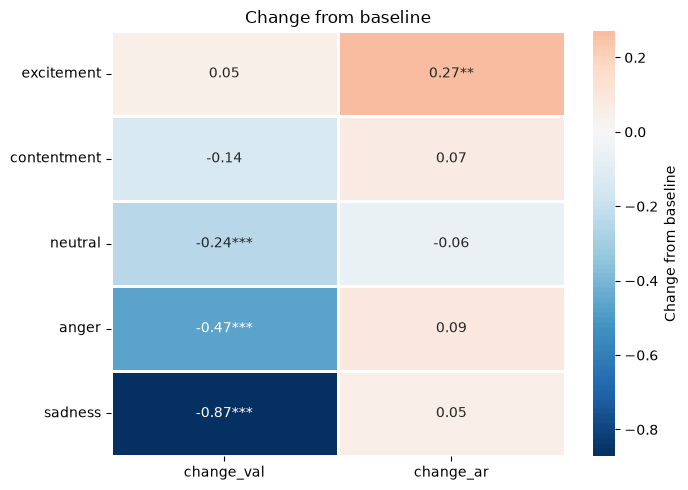

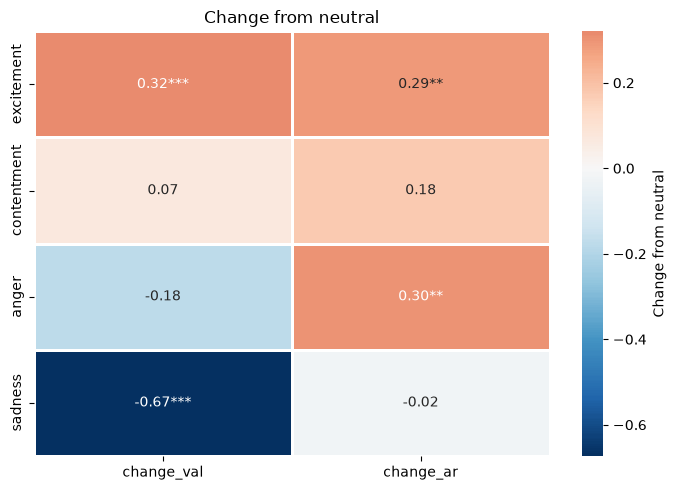

In [90]:
# Significance function
def significance_marker(p):
    # if p < 0.0005:
    #     return " (p < 0.001)"
    # return f" (p = {p:.3f})"
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

df = df_emo
# Create matrix of change values
heatmap_data = df.set_index('Emotion')[['change_val', 'change_ar']]

# Create annotation matrix with change + significance
annotations = np.empty(heatmap_data.shape, dtype=object)

for i, emotion in enumerate(df['Emotion']):
    annotations[i, 0] = (
        f"{df.loc[i, 'change_val']:.2f}"
        f"{significance_marker(df.loc[i, 'p-values_val'])}"
    )
    
    annotations[i, 1] = (
        f"{df.loc[i, 'change_ar']:.2f}"
        f"{significance_marker(df.loc[i, 'p-values_ar'])}"
    )

# Plot
plt.figure(figsize=(7, 5))

sns.heatmap(
    heatmap_data,
    annot=annotations,
    fmt='',
    cmap='RdBu_r',
    center=0,
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Change from baseline'}
)

plt.xlabel('')
plt.ylabel('')
plt.title('Change from baseline')

plt.tight_layout()
plt.savefig(
    'figures/emotion_change_heatmap.pdf',
    bbox_inches='tight'
)

plt.show()

df = df_emo2
# Create matrix of change values
heatmap_data = df.set_index('Emotion')[['change_val', 'change_ar']]

# Create annotation matrix with change + significance
annotations = np.empty(heatmap_data.shape, dtype=object)

for i, emotion in enumerate(df['Emotion']):
    annotations[i, 0] = (
        f"{df.loc[i, 'change_val']:.2f}"
        f"{significance_marker(df.loc[i, 'p-values_val'])}"
    )
    
    annotations[i, 1] = (
        f"{df.loc[i, 'change_ar']:.2f}"
        f"{significance_marker(df.loc[i, 'p-values_ar'])}"
    )

# Plot
plt.figure(figsize=(7, 5))

sns.heatmap(
    heatmap_data,
    annot=annotations,
    fmt='',
    cmap='RdBu_r',
    center=0,
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Change from neutral'}
)

plt.xlabel('')
plt.ylabel('')
plt.title('Change from neutral')

plt.tight_layout()
plt.savefig(
    'figures/emotion_change_neutral_heatmap.pdf',
    bbox_inches='tight'
)

plt.show()

## Statistics on Extracted Features

### Correlation Matrix

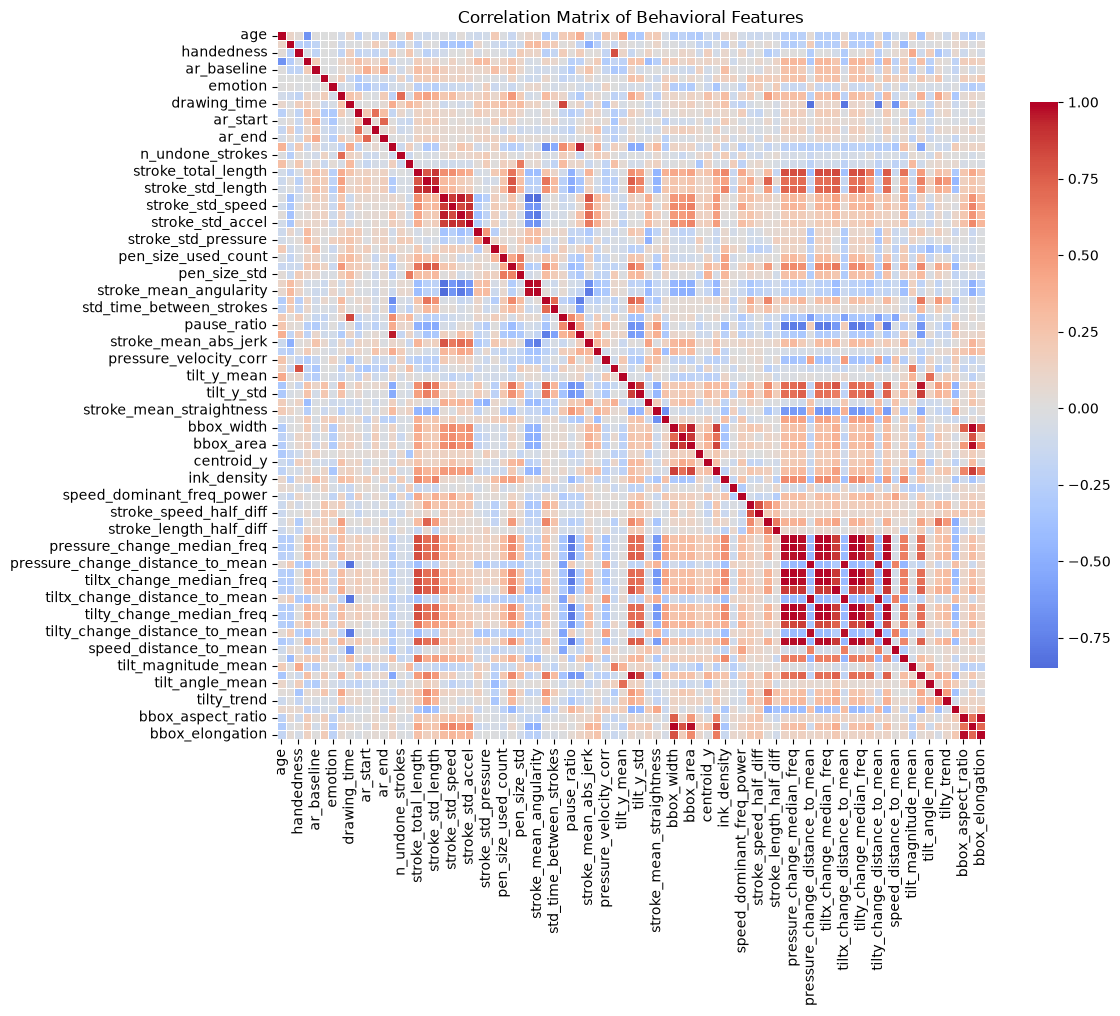

In [96]:
exclude_columns = ["participant_id", "emotion_name", "emotion_3_way", "emotion_3_way_arousal"]

# Select behavioral features only
behavioral_df = features_df.drop(columns=exclude_columns, errors="ignore")
corr_matrix = behavioral_df.corr(method="pearson")

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Behavioral Features")
plt.savefig("figures/correlation_matrix_full_set.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()


### Remove Highly Correlated Pairs

In [97]:
# Find high correlations
high_corr_pairs = []

threshold = 0.85

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((col1, col2, value))

# Print results
print("\nHighly correlated feature pairs (|r| > 0.85):")
for pair in high_corr_pairs:
    print(f"{pair[0]}  <->  {pair[1]}  : r = {pair[2]:.3f}")



Highly correlated feature pairs (|r| > 0.85):
stroke_std_length  <->  stroke_total_length  : r = 0.886
stroke_std_length  <->  stroke_mean_length  : r = 0.927
stroke_std_speed  <->  stroke_mean_speed  : r = 0.872
stroke_mean_accel  <->  stroke_mean_speed  : r = 0.956
stroke_std_accel  <->  stroke_mean_speed  : r = 0.862
stroke_std_accel  <->  stroke_std_speed  : r = 0.916
stroke_std_accel  <->  stroke_mean_accel  : r = 0.904
stroke_mean_angularity  <->  stroke_mean_curvature  : r = 0.972
stroke_frequency  <->  n_strokes  : r = 0.951
tilt_y_std  <->  tilt_x_std  : r = 0.864
bbox_area  <->  bbox_width  : r = 0.945
bbox_area  <->  bbox_height  : r = 0.882
spatial_spread  <->  bbox_width  : r = 0.860
pressure_change_median_freq  <->  pressure_change_bandwidth  : r = 0.999
pressure_change_peaks_per_sec  <->  pressure_change_bandwidth  : r = 0.973
pressure_change_peaks_per_sec  <->  pressure_change_median_freq  : r = 0.971
tiltx_change_bandwidth  <->  pressure_change_bandwidth  : r = 0.999


Dropping 'pressure_change_peaks_per_sec' (degree=9, correlated with: ['pressure_change_bandwidth', 'pressure_change_median_freq', 'tiltx_change_bandwidth', 'tiltx_change_median_freq', 'tiltx_change_peaks_per_sec', 'tilty_change_bandwidth', 'tilty_change_median_freq', 'tilty_change_peaks_per_sec', 'speed_peaks_per_sec'])
Dropping 'tiltx_change_bandwidth' (degree=7, correlated with: ['pressure_change_bandwidth', 'pressure_change_median_freq', 'tiltx_change_median_freq', 'tiltx_change_peaks_per_sec', 'tilty_change_bandwidth', 'tilty_change_median_freq', 'speed_peaks_per_sec'])
Dropping 'tiltx_change_peaks_per_sec' (degree=6, correlated with: ['pressure_change_bandwidth', 'pressure_change_median_freq', 'tiltx_change_median_freq', 'tilty_change_bandwidth', 'tilty_change_median_freq', 'speed_peaks_per_sec'])
Dropping 'pressure_change_bandwidth' (degree=5, correlated with: ['pressure_change_median_freq', 'tiltx_change_median_freq', 'tilty_change_bandwidth', 'tilty_change_median_freq', 'speed_

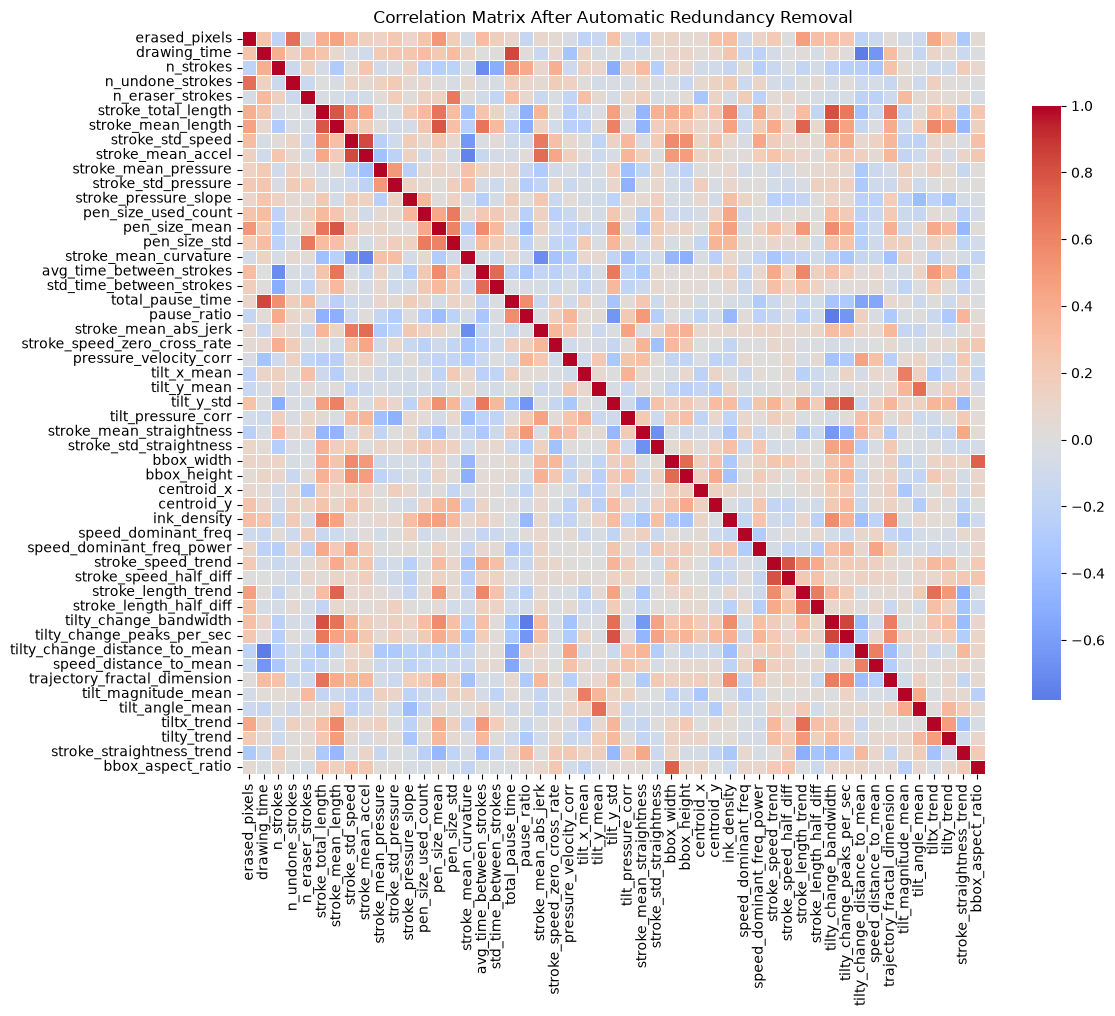


Dropped features (21):
  - pressure_change_peaks_per_sec
  - tiltx_change_bandwidth
  - tiltx_change_peaks_per_sec
  - pressure_change_bandwidth
  - tiltx_change_median_freq
  - pressure_change_median_freq
  - stroke_mean_speed
  - bbox_area
  - speed_peaks_per_sec
  - tilt_x_std
  - stroke_std_length
  - spatial_spread
  - tiltx_change_distance_to_mean
  - stroke_std_accel
  - tilty_change_median_freq
  - tilt_magnitude_std
  - stroke_mean_angularity
  - pressure_change_distance_to_mean
  - stroke_frequency
  - bbox_diagonal
  - bbox_elongation

Retained features (51):
  - erased_pixels
  - drawing_time
  - n_strokes
  - n_undone_strokes
  - n_eraser_strokes
  - stroke_total_length
  - stroke_mean_length
  - stroke_std_speed
  - stroke_mean_accel
  - stroke_mean_pressure
  - stroke_std_pressure
  - stroke_pressure_slope
  - pen_size_used_count
  - pen_size_mean
  - pen_size_std
  - stroke_mean_curvature
  - avg_time_between_strokes
  - std_time_between_strokes
  - total_pause_time
  

In [98]:
import networkx as nx

def auto_remove_correlated_features(df, exclude_columns=None, threshold=0.85, method="pearson", verbose=True):
    exclude_columns = exclude_columns or []
    behavioral_df = df.drop(columns=exclude_columns, errors="ignore")
    behavioral_df = behavioral_df.select_dtypes(include=[np.number])

    working_df = behavioral_df.copy()
    dropped_features = []

    while True:
        corr_matrix = working_df.corr(method=method)

        # find all pairs above threshold
        high_corr_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i):
                if abs(corr_matrix.iloc[i, j]) > threshold:
                    col1 = corr_matrix.columns[i]
                    col2 = corr_matrix.columns[j]
                    value = corr_matrix.iloc[i, j]
                    high_corr_pairs.append((col1, col2, value))

        if not high_corr_pairs:
            break

        # build a graph: nodes = features, edges = high-correlation pairs
        G = nx.Graph()
        G.add_nodes_from(working_df.columns)
        for col1, col2, _ in high_corr_pairs:
            G.add_edge(col1, col2)

        # drop the node with the highest degree (most redundant connections);
        # break ties by dropping the one with higher mean |correlation|
        # across the whole current feature set (more generically redundant)
        degrees = dict(G.degree())
        max_degree = max(degrees.values())
        candidates = [f for f, d in degrees.items() if d == max_degree]

        if len(candidates) > 1:
            mean_abs_corr = corr_matrix.abs().mean()
            candidates.sort(key=lambda f: mean_abs_corr[f], reverse=True)

        feature_to_drop = candidates[0]

        if verbose:
            connected_to = list(G.neighbors(feature_to_drop))
            print(f"Dropping '{feature_to_drop}' (degree={max_degree}, "
                  f"correlated with: {connected_to})")

        working_df = working_df.drop(columns=[feature_to_drop])
        dropped_features.append(feature_to_drop)

    if verbose:
        print(f"\nTotal features dropped: {len(dropped_features)}")
        print(f"Features remaining: {working_df.shape[1]}")
        if len(high_corr_pairs) == 0 and len(dropped_features) == 0:
            print("No highly correlated pairs found — nothing removed.")

    return working_df, dropped_features, working_df.corr(method=method)


# --- Usage ---
non_features = [
    "participant_id", "emotion_name", "handedness", "age", "gender",
    "emotion", "round", "val_start", "ar_start", "val_end", "ar_end",
    "val_baseline", "ar_baseline", "emotion_3_way", "emotion_3_way_arousal"
]

reduced_df, dropped_features, final_corr_matrix = auto_remove_correlated_features(
    features_df, exclude_columns=non_features, threshold=0.85
)

# Visualize the final, decorrelated matrix
plt.figure(figsize=(12, 10))
sns.heatmap(final_corr_matrix, cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix After Automatic Redundancy Removal")
plt.savefig("figures/correlation_matrix_auto_reduced.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

print(f"\nDropped features ({len(dropped_features)}):")
for f in dropped_features:
    print(f"  - {f}")

print(f"\nRetained features ({reduced_df.shape[1]}):")
for f in reduced_df.columns:
    print(f"  - {f}")

In [99]:
exclude_columns = non_features + dropped_features
exclude_columns

['participant_id',
 'emotion_name',
 'handedness',
 'age',
 'gender',
 'emotion',
 'round',
 'val_start',
 'ar_start',
 'val_end',
 'ar_end',
 'val_baseline',
 'ar_baseline',
 'emotion_3_way',
 'emotion_3_way_arousal',
 'pressure_change_peaks_per_sec',
 'tiltx_change_bandwidth',
 'tiltx_change_peaks_per_sec',
 'pressure_change_bandwidth',
 'tiltx_change_median_freq',
 'pressure_change_median_freq',
 'stroke_mean_speed',
 'bbox_area',
 'speed_peaks_per_sec',
 'tilt_x_std',
 'stroke_std_length',
 'spatial_spread',
 'tiltx_change_distance_to_mean',
 'stroke_std_accel',
 'tilty_change_median_freq',
 'tilt_magnitude_std',
 'stroke_mean_angularity',
 'pressure_change_distance_to_mean',
 'stroke_frequency',
 'bbox_diagonal',
 'bbox_elongation']

In [100]:
# Find high correlations
high_corr_pairs = []

threshold = 0.85

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((col1, col2, value))

# Print results
if not high_corr_pairs:
    print("No highly correlated pairs remaining")
else:
    print("\nHighly correlated feature pairs (|r| > 0.85):")
    for pair in high_corr_pairs:
        print(f"{pair[0]}  <->  {pair[1]}  : r = {pair[2]:.3f}")



Highly correlated feature pairs (|r| > 0.85):
stroke_std_length  <->  stroke_total_length  : r = 0.886
stroke_std_length  <->  stroke_mean_length  : r = 0.927
stroke_std_speed  <->  stroke_mean_speed  : r = 0.872
stroke_mean_accel  <->  stroke_mean_speed  : r = 0.956
stroke_std_accel  <->  stroke_mean_speed  : r = 0.862
stroke_std_accel  <->  stroke_std_speed  : r = 0.916
stroke_std_accel  <->  stroke_mean_accel  : r = 0.904
stroke_mean_angularity  <->  stroke_mean_curvature  : r = 0.972
stroke_frequency  <->  n_strokes  : r = 0.951
tilt_y_std  <->  tilt_x_std  : r = 0.864
bbox_area  <->  bbox_width  : r = 0.945
bbox_area  <->  bbox_height  : r = 0.882
spatial_spread  <->  bbox_width  : r = 0.860
pressure_change_median_freq  <->  pressure_change_bandwidth  : r = 0.999
pressure_change_peaks_per_sec  <->  pressure_change_bandwidth  : r = 0.973
pressure_change_peaks_per_sec  <->  pressure_change_median_freq  : r = 0.971
tiltx_change_bandwidth  <->  pressure_change_bandwidth  : r = 0.999


### Stability Selection

In [101]:
# Define classifiers
classifiers = [
    {
        'name': "LogisticRegression",
        'model': LogisticRegression(
            max_iter=10000,
            class_weight="balanced",
            l1_ratio=0.0,
            C=0.1,
        ),
        'use_importance': False
    },
    {
        'name': "LinearSVM",
        'model': SVC(
            kernel="linear",
            probability=True,     # needed for ROC-AUC
            decision_function_shape="ovr"
        ),
        'use_importance': False
    },
    # {
    #     'name': "NaiveBayes",
    #     'model': GaussianNB(),
    #     'use_importance': False
    # },
    # {
    #     'name': "KNN",
    #     'model': KNeighborsClassifier(
    #         n_neighbors=5
    #     ),
    #     'use_importance': False
    # },
    {
        'name': "RandomForest",
        'model': RandomForestClassifier(
        n_estimators=300,
        max_depth=3,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=0
        ),
        'use_importance': True
    },
    {
        'name': "GradientBoosting",
        'model': GradientBoostingClassifier(
            n_estimators=100,
            max_depth=2,
            learning_rate=0.05,
            subsample=0.8,
            random_state=0
        ),
        'use_importance': True,
    },
]


In [104]:
selector = VarianceThreshold(threshold=0.01)  # tune based on your scaled features
X = features_df.drop(columns=exclude_columns)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

threshold=0.01
selector = VarianceThreshold(threshold=threshold)
X_filtered = selector.fit_transform(X_scaled)
kept_cols = X_scaled.columns[selector.get_support()]
dropped_cols = X_scaled.columns[~selector.get_support()]
if len(dropped_cols) > 0:
    print(f"Dropped {len(dropped_cols)} near-zero-variance features: {list(dropped_cols)}")
else:
    print("No features had near-zero-variance!")
X_composite_filtered = pd.DataFrame(X_filtered, columns=kept_cols, index=X.index)


No features had near-zero-variance!


In [105]:
def stability_selection(X, y, groups, model, top_k=None, use_importances=True, non_zero=False):
    logo = LeaveOneGroupOut()
    n_folds = logo.get_n_splits(X, y, groups)
    selection_counts = defaultdict(int)

    for train_idx, _ in logo.split(X, y, groups):
        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]

        scaler_fold = StandardScaler()
        X_train_scaled = scaler_fold.fit_transform(X_train)
        model.fit(X_train_scaled, y_train)
        
        if use_importances:
            importances = model.feature_importances_
        else:
            importances = np.max(model.coef_, axis=0)

        if top_k is not None:
            # select the top_k most important features this fold
            threshold_val = np.sort(importances)[-top_k]
            nonzero_mask = importances >= threshold_val
        elif non_zero:    
            nonzero_mask = np.any(importances != 0, axis=0)
        else:
            # default: above-average importance for this fold
            # equivalent to: top_k = features // 2; here 26
            nonzero_mask = importances >= np.mean(importances)
        
        for col, selected in zip(X.columns, nonzero_mask):
            if selected:
                selection_counts[col] += 1

    stability_df = pd.DataFrame({
        "feature": list(X.columns),
        "n_folds_selected": [selection_counts.get(c, 0) for c in X.columns],
        "fraction_folds_selected": [selection_counts.get(c, 0) / n_folds for c in X.columns]
    }).sort_values("fraction_folds_selected", ascending=False)

    return stability_df

In [106]:
# Prepare data
y_5_way = features_df["emotion_name"]
y_3_way = features_df["emotion_3_way"]
groups = features_df["participant_id"]

# Define Validation method
# Leave-One-Group-Out Cross Validation (LOGO CV)
# -> train on n-1 participants, test on 1 participant, repeat n times. Group = 1 participant with 2 conditions
logo = LeaveOneGroupOut()

In [107]:
THRESHOLD = 0.6
for classifier in classifiers:
    model = classifier['model']
    use_importance = classifier['use_importance']
    
    stability_3_way = stability_selection(
        X_composite_filtered, y_3_way, groups, model, use_importances=use_importance, top_k=15
    )
    selected_features = stability_3_way[stability_3_way['fraction_folds_selected'] >= THRESHOLD]
    classifier['features_3_way'] = list(selected_features['feature'])

    stability_5_way = stability_selection(
        X_composite_filtered, y_5_way, groups, model, use_importances=use_importance, top_k=15
    )
    selected_features = stability_5_way[stability_5_way['fraction_folds_selected'] >= THRESHOLD]
    classifier['features_5_way'] = list(selected_features['feature'])

/usr/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensem

In [108]:
for classifier in classifiers:
    name = classifier['name']
    n_3w = len(classifier['features_3_way'])
    n_5w = len(classifier['features_5_way'])

    print(f"{name}: 3W features: {n_3w}; 5W features: {n_5w}")

LogisticRegression: 3W features: 14; 5W features: 12
LinearSVM: 3W features: 16; 5W features: 15
RandomForest: 3W features: 12; 5W features: 9
GradientBoosting: 3W features: 14; 5W features: 13


## Classification Models

Here we test how well models can predict emotion labels ('excitement', 'anger', 'sadness', 'contentment', and 'neutral').

### Multiclass Classification

Tests all classifiers for accuracy

In [109]:
def multi_class_classification(X, y, groups, group_labels, name, clf, prefix=""):
    # Setup Pipeline and standardizer
    pipeline = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    y_true = []
    y_pred = []
    y_proba = []  # will hold full probability matrix rows

    fold_importances = []

    # Train and test
    for train_idx, test_idx in logo.split(X, y, groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_test)
        probas = pipeline.predict_proba(X_test)  # shape (n_samples, n_classes)

        y_true.extend(y_test)
        y_pred.extend(preds)
        y_proba.extend(probas)  # list of per-sample probability arrays

        # --- permutation importance on test fold ---
        result = permutation_importance(
            pipeline,
            X_test,
            y_test,
            n_repeats=50,
            random_state=42,
            scoring="accuracy"
        )

        fold_importances.append(result.importances_mean)

    fold_importances = np.array(fold_importances)
    y_proba = np.array(y_proba)  # (n_samples, n_classes)

    # Performance metrics
    acc = accuracy_score(y_true, y_pred)

    # Multiclass ROC-AUC: macro-average, one-vs-rest
    # requires probability estimates for every class, and labels param
    # to make sure the class order matches y_proba's column order
    pipeline_classes = pipeline.named_steps["clf"].classes_
    roc_auc = roc_auc_score(
        y_true,
        y_proba,
        multi_class="ovr",
        average="macro",
        labels=pipeline_classes
    )

    cm = confusion_matrix(y_true, y_pred)

    # Permutation test (how much the model is better than random chance)
    score, perm_scores, pvalue = permutation_test_score(
        pipeline,
        X,
        y,
        groups=groups,
        cv=logo,
        scoring="accuracy",
        n_permutations=1000,
        n_jobs=-1
    )

    results = {"Classifier": name, "Accuracy": acc, "ROC_AUC_macro": roc_auc, "Permutation_p": pvalue}

    print(f"\n{name}")
    print("Confusion Matrix:")
    print(cm)
    print(f"Accuracy: {acc:.3f}")
    print(f"ROC-AUC (macro OVR): {roc_auc:.3f}")
    print(f"Permutation p-value: {pvalue:.4f}")

    disp = ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        cmap="Blues",
        display_labels=group_labels
    )

    ax = disp.ax_
    plt.setp(ax.get_xticklabels(), rotation=0)
    plt.setp(ax.get_yticklabels(), rotation=90, va='center')
    plt.title("Confusion Matrix")
    fig_name_matrix = "figures/" + prefix + name + "_confusion_matrix.pdf"
    plt.savefig(fig_name_matrix, dpi=300, bbox_inches="tight")
    plt.show()

    # Multiclass ROC: one curve per class (one-vs-rest)
    y_true_arr = np.array(y_true)
    plt.figure()
    for i, cls in enumerate(pipeline_classes):
        fpr, tpr, _ = roc_curve((y_true_arr == cls).astype(int), y_proba[:, i])
        class_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {class_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (One-vs-Rest)")
    plt.legend()

    fig_name_roc = "figures/" + prefix + name + "_roc_curve.pdf"
    plt.savefig(fig_name_roc, dpi=300, bbox_inches="tight")
    plt.show()
    
    return results, fold_importances

In [110]:
def print_results(results, all_importances, classifier_names, features):
    # Summary table
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values("Accuracy", ascending=False)

    print("\n=== Classifier Comparison ===")
    print(results_df)


    importance_tables = {}

    for name in classifier_names:
        importances = all_importances[name]

        importance_df = pd.DataFrame({
            "feature": features[name].columns,
            "importance_mean": importances.mean(axis=0),
            "importance_std": importances.std(axis=0)
        })

        importance_df = importance_df.sort_values(
            "importance_mean",
            ascending=False
        )

        importance_tables[name] = importance_df

        print(f"\n=== Feature Importance ({name}) ===")
        print(importance_df.head(10))
    return results_df, importance_tables

### 5-way classification


LogisticRegression
Confusion Matrix:
[[ 4  2  1  2  3]
 [ 1  4  1  3  3]
 [ 0  0 10  1  2]
 [ 6  7  4  3  5]
 [ 3  2  3  3  2]]
Accuracy: 0.307
ROC-AUC (macro OVR): 0.642
Permutation p-value: 0.0420


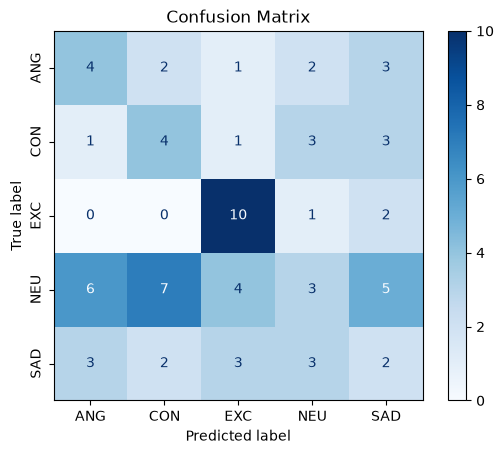

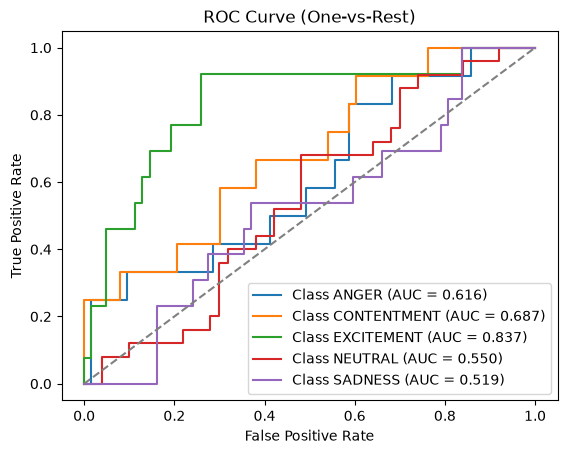

c:\Users\Tamara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Tamara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Tamara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Tamara\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\


LinearSVM
Confusion Matrix:
[[ 2  1  1  4  4]
 [ 1  3  2  4  2]
 [ 0  3  5  4  1]
 [ 4  4  4 11  2]
 [ 4  0  3  4  2]]
Accuracy: 0.307
ROC-AUC (macro OVR): 0.490
Permutation p-value: 0.1149


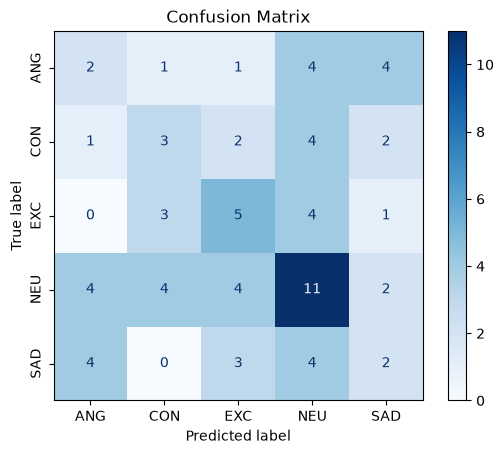

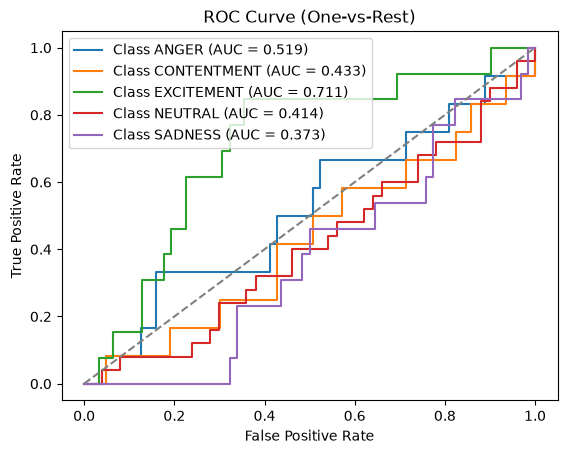


RandomForest
Confusion Matrix:
[[6 1 1 1 3]
 [2 5 3 2 0]
 [1 3 8 0 1]
 [3 8 4 8 2]
 [4 2 2 4 1]]
Accuracy: 0.373
ROC-AUC (macro OVR): 0.646
Permutation p-value: 0.0020


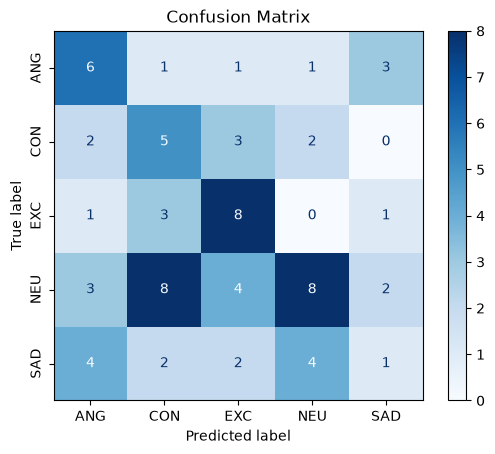

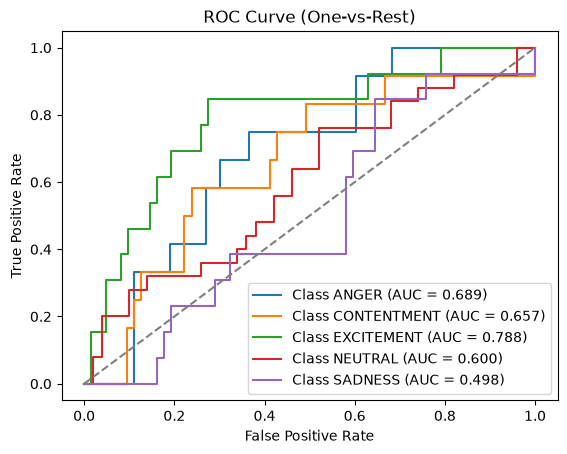


GradientBoosting
Confusion Matrix:
[[ 2  1  1  7  1]
 [ 0  3  4  4  1]
 [ 0  2  5  2  4]
 [ 3  3  2 16  1]
 [ 1  2  2  5  3]]
Accuracy: 0.387
ROC-AUC (macro OVR): 0.636
Permutation p-value: 0.0220


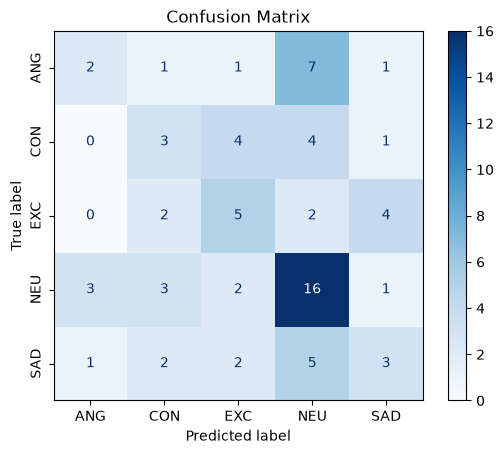

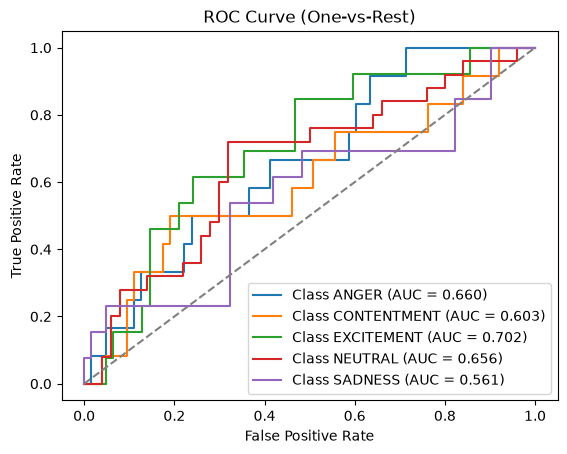


=== Classifier Comparison ===
           Classifier  Accuracy  ROC_AUC_macro  Permutation_p
3    GradientBoosting  0.386667       0.636451       0.021978
2        RandomForest  0.373333       0.646384       0.001998
1           LinearSVM  0.306667       0.489965       0.114885
0  LogisticRegression  0.306667       0.641718       0.041958

=== Feature Importance (LogisticRegression) ===
                    feature  importance_mean  importance_std
2               bbox_height         0.047467        0.089031
4   stroke_length_half_diff         0.028000        0.067882
9          n_eraser_strokes         0.024533        0.099666
1   stroke_std_straightness         0.022133        0.143477
6               tilt_x_mean         0.018933        0.043764
5       speed_dominant_freq         0.015200        0.086667
0             pen_size_mean         0.007733        0.086609
11          tilt_angle_mean        -0.001333        0.056253
8        stroke_speed_trend        -0.003733        0.114217


In [21]:
five_way = ['ANG', "CON", "EXC", "NEU", "SAD"]
all_results = []
all_importances = {}
classifier_names = [classifier['name'] for classifier in classifiers]
features = {}

for classifier in classifiers:
    X_5_way = features_df[classifier['features_5_way']].select_dtypes(include=[np.number])
    name = classifier['name']
    clf = classifier['model']
    results, importance = multi_class_classification(X_5_way, y_5_way, groups, five_way, name, clf, "5w_")
    all_results.append(results)
    all_importances[name] = importance
    features[name] = X_5_way

results_df, importance_tables = print_results(all_results, all_importances, classifier_names, features)

### 3-way classification


LogisticRegression
Confusion Matrix:
[[15  5  5]
 [ 9  9  7]
 [ 7  5 13]]
Accuracy: 0.493
ROC-AUC (macro OVR): 0.731
Permutation p-value: 0.0050


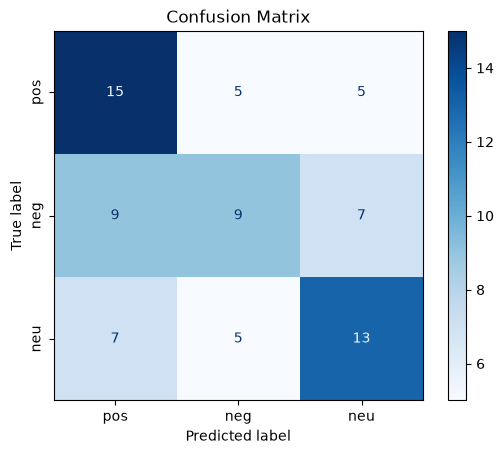

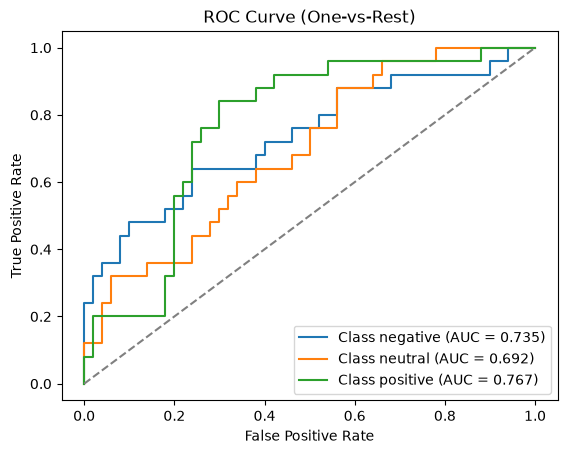


=== Classifier Comparison ===
           Classifier  Accuracy  ROC_AUC_macro  Permutation_p
0  LogisticRegression  0.493333       0.731467       0.004995

=== Feature Importance (LogisticRegression) ===
                          feature  importance_mean  importance_std
11                  pen_size_mean         0.026133        0.108122
13           stroke_mean_pressure         0.018933        0.095269
2                     pause_ratio         0.013333        0.104068
3               bbox_aspect_ratio         0.009067        0.104152
4                     bbox_height         0.007733        0.135143
1           stroke_pressure_slope         0.006133        0.142460
9                 tilt_angle_mean        -0.000800        0.071438
5         stroke_std_straightness        -0.003200        0.102469
6   tilty_change_distance_to_mean        -0.003200        0.100596
0           stroke_mean_curvature        -0.004267        0.079171


In [111]:
three_way = ['pos', 'neg', 'neu']
all_results = []
all_importances = {}
classifier_names = [classifier['name'] for classifier in classifiers]
features = {}

for classifier in classifiers:
    X_3_way = features_df[classifier['features_3_way']].select_dtypes(include=[np.number])
    name = classifier['name']
    clf = classifier['model']
    results, importance = multi_class_classification(X_3_way, y_3_way, groups, three_way, name, clf, "3w_")
    all_results.append(results)
    all_importances[name] = importance
    features[name] = X_3_way
    break

results_df, importance_tables = print_results(all_results, all_importances, classifier_names[:1], features)

## (depreacated)

### Two Classes classification

In [201]:
df_reduced = features_df[features_df['emotion_name'] != "NEUTRAL"]
X_2_way = X_stable_emotion_3_way[features_df['emotion_name'] != "NEUTRAL"]
X_2_way = X_2_way.select_dtypes(include=[np.number])

y_2_way = df_reduced["emotion_3_way"]
groups_2_way = df_reduced["participant_id"]

In [202]:
def two_class_classification(X, y, groups, group_labels, classifiers):
    # Loop over the classifiers
    results = []
    all_importances = {}
    for name, clf in classifiers.items():

        # Setup Pipeline and standardizer
        pipeline = Pipeline([("scaler", StandardScaler()), ("clf", clf)])

        y_true = []
        y_pred = []
        y_proba = []

        fold_importances = []

        # Train and test
        for train_idx, test_idx in logo.split(X, y, groups):

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            pipeline.fit(X_train, y_train)

            preds = pipeline.predict(X_test)
            probas = pipeline.predict_proba(X_test)[:, 1]

            y_true.extend(y_test)
            y_pred.extend(preds)
            y_proba.extend(probas)

            # --- permutation importance on test fold ---
            result = permutation_importance(
                pipeline,
                X_test,
                y_test,
                n_repeats=50,
                random_state=42,
                scoring="accuracy"
            )

            fold_importances.append(result.importances_mean)

        fold_importances = np.array(fold_importances)
        all_importances[name] = fold_importances

        # Performance metrics
        # Confusion matrix
        # [[TN  FP]
        # [FN  TP]]
        # The ROC curve is the plot of the true positive rate (TPR = TP/P) against the false positive rate (FPR = FP/N) at each threshold setting.
        # Variation of the probability threshold distinguishing if a prediction is of one class or the other 
        acc = accuracy_score(y_true, y_pred)
        fpr, tpr, thresholds = roc_curve(y_true, y_proba, pos_label="positive")
        roc_auc = auc(fpr, tpr)
        cm = confusion_matrix(y_true, y_pred)

        # Permutation test (how much the model is better than random chance)
        # Allows to say if the obtained accuracy when training with the real data is better than when trained with randomized output
        score, perm_scores, pvalue = permutation_test_score(
            pipeline,
            X,
            y,
            groups=groups,
            cv=logo,
            scoring="accuracy",
            n_permutations=1000,
            n_jobs=-1)

        results.append({"Classifier": name, "Accuracy": acc, "ROC_AUC": roc_auc, "Permutation_p": pvalue})

        print(f"\n{name}")
        print("Confusion Matrix:")
        print(cm)
        print(f"Accuracy: {acc:.3f}")
        print(f"ROC-AUC: {roc_auc:.3f}")
        print(f"Permutation p-value: {pvalue:.4f}")

        disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=group_labels, cmap="Blues")


        ax = disp.ax_  # get the axis

        # Fix label orientation and alignment
        plt.setp(ax.get_xticklabels(), rotation=0)
        plt.setp(ax.get_yticklabels(), rotation=90, va='center')

        plt.title("Confusion Matrix")

        fig_name_matrix = "figures/" + name + "_confusion_matrix_2_way.pdf"
        plt.savefig(fig_name_matrix, bbox_inches="tight")

        plt.show()

        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        plt.plot([0,1], [0,1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()

        fig_name_roc = "figures/" + name + "_roc_curve_2_way.pdf"
        plt.savefig(fig_name_roc, dpi=300, bbox_inches="tight")
        plt.show()


    # Summary table
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values("Accuracy", ascending=False)

    print("\n=== Classifier Comparison ===")
    print(results_df)

    

    importance_tables = {}

    for name in classifiers.keys():

        importances = all_importances[name]

        importance_df = pd.DataFrame({
            "feature": X.columns,
            "importance_mean": importances.mean(axis=0),
            "importance_std": importances.std(axis=0)
        })

        importance_df = importance_df.sort_values(
            "importance_mean",
            ascending=False
        )

        importance_tables[name] = importance_df

        print(f"\n=== Feature Importance ({name}) ===")
        print(importance_df.head(10))
    return results_df, importance_tables


LogisticRegression
Confusion Matrix:
[[16  9]
 [ 8 17]]
Accuracy: 0.660
ROC-AUC: 0.707
Permutation p-value: 0.0340


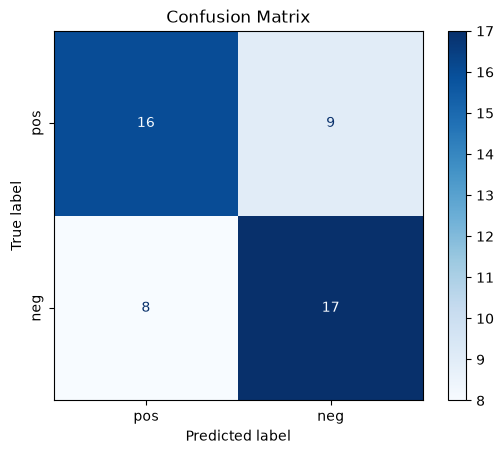

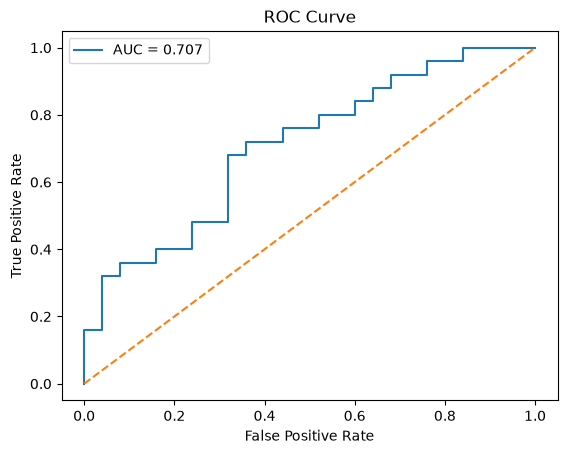


=== Classifier Comparison ===
           Classifier  Accuracy  ROC_AUC  Permutation_p
0  LogisticRegression      0.66   0.7072       0.033966

=== Feature Importance (LogisticRegression) ===
                      feature  importance_mean  importance_std
2               pen_size_mean             0.06        0.146287
9                 bbox_height             0.04        0.091652
8                 pause_ratio             0.03        0.081240
13        speed_dominant_freq             0.03        0.107703
11     stroke_speed_half_diff             0.02        0.140000
4        stroke_mean_pressure             0.02        0.067823
12  speed_dominant_freq_power             0.02        0.156844
19            warm_cool_ratio             0.02        0.067823
15              bbox_diagonal             0.02        0.067823
0         stroke_std_pressure             0.01        0.048990


In [203]:
results, importance = two_class_classification(X_2_way, y_2_way, groups_2_way, ['pos', "neg"], classifiers)

### Regression Analysis

Here we test how well models can predict the participant's level of valence and arousal

In [6]:
# Prepare data
X = features_df.drop(columns=exclude_columns, errors="ignore")
X = X.select_dtypes(include=[np.number])

groups = features_df["participant_id"]

y_valence = features_df['val_start']
y_arousal = features_df['ar_start']


In [7]:
class PLSRegressionWrapper(PLSRegression):
    def predict(self, X):
        return super().predict(X).ravel()

# Define regressors
regressors = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
    "PLS": PLSRegressionWrapper(n_components=3),
    "SVR_linear": SVR(kernel="linear", C=1.0),
    "SVR_rbf": SVR(kernel="rbf", C=1.0, gamma="scale"),
    "Dummy_mean": DummyRegressor(strategy="mean"),
}


Ridge (valence)
R2: -2.139
MAE: 0.611
Pearson r: -0.077 (p=0.5104)
Permutation p-value (R2): 0.5455


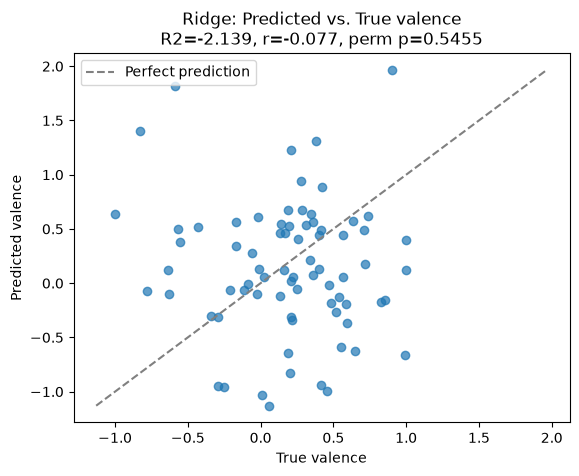

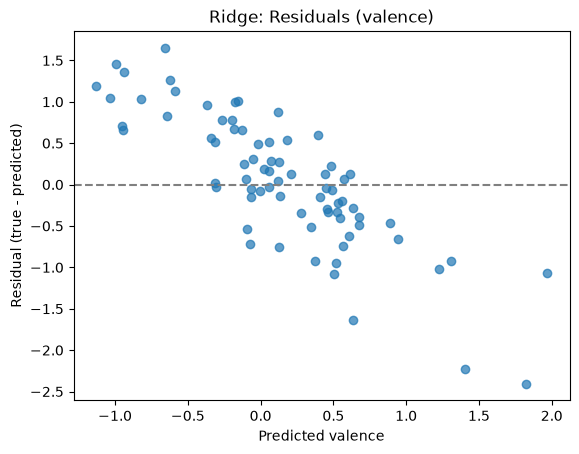


Lasso (valence)
R2: -0.037
MAE: 0.348
Pearson r: -0.190 (p=0.1030)
Permutation p-value (R2): 0.3447


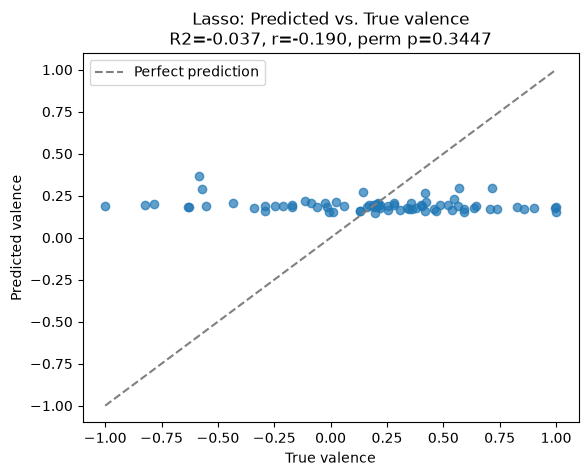

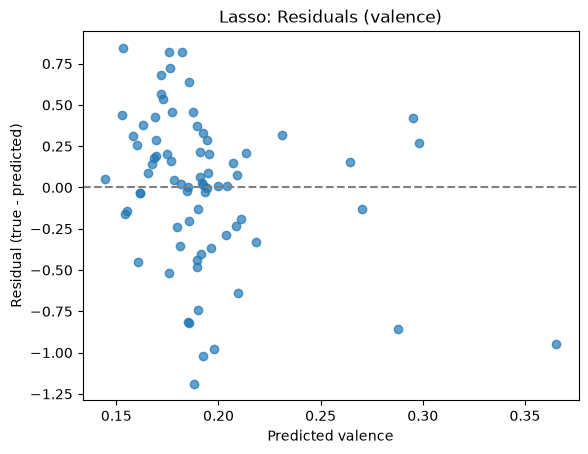


ElasticNet (valence)
R2: -0.076
MAE: 0.346
Pearson r: -0.031 (p=0.7890)
Permutation p-value (R2): 0.3257


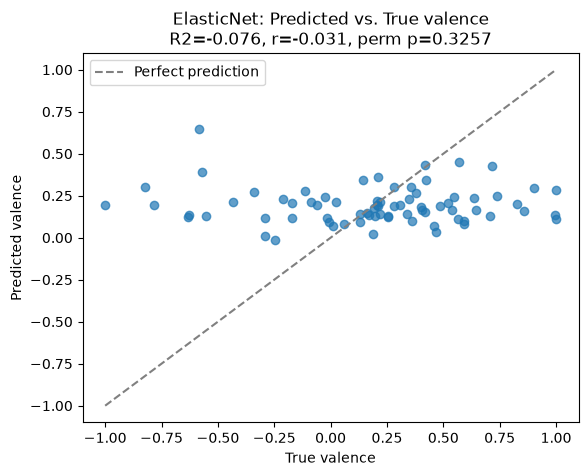

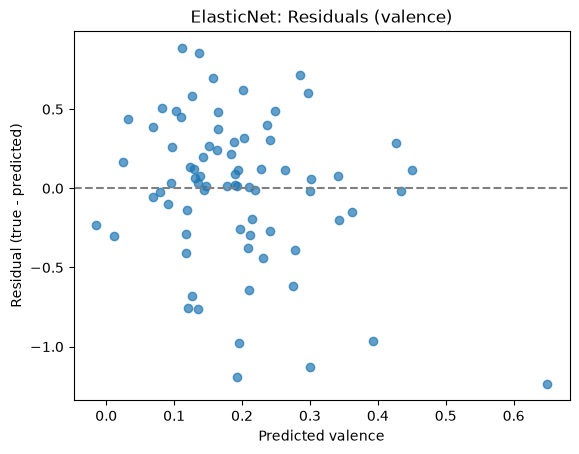


PLS (valence)
R2: -0.411
MAE: 0.395
Pearson r: -0.033 (p=0.7759)
Permutation p-value (R2): 0.3556


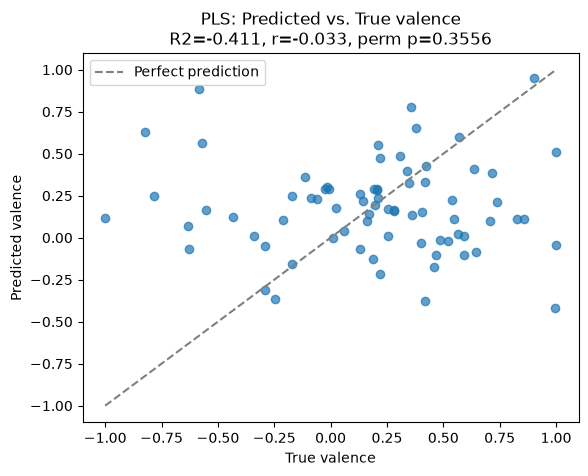

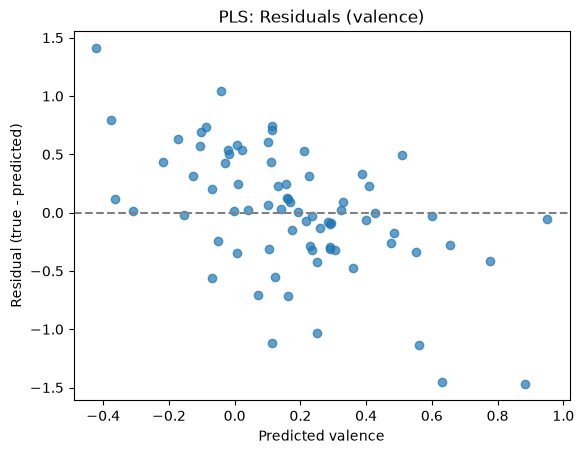


SVR_linear (valence)
R2: -2.371
MAE: 0.611
Pearson r: -0.036 (p=0.7604)
Permutation p-value (R2): 0.1518


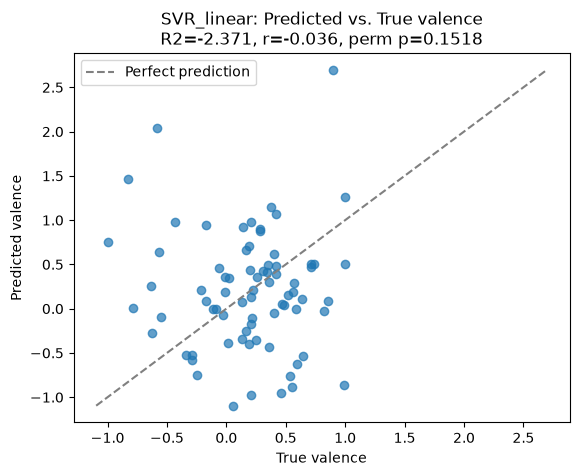

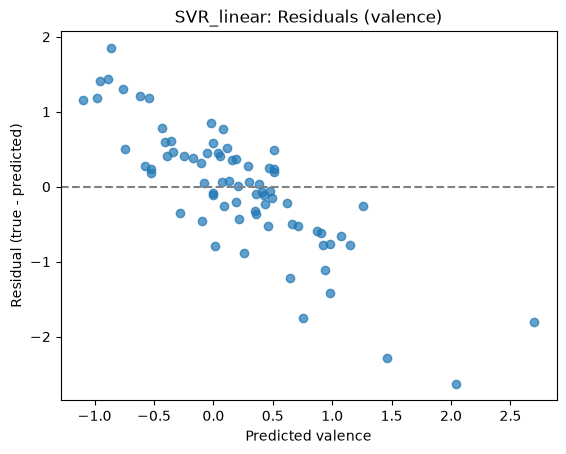


SVR_rbf (valence)
R2: -0.202
MAE: 0.369
Pearson r: -0.093 (p=0.4285)
Permutation p-value (R2): 0.4545


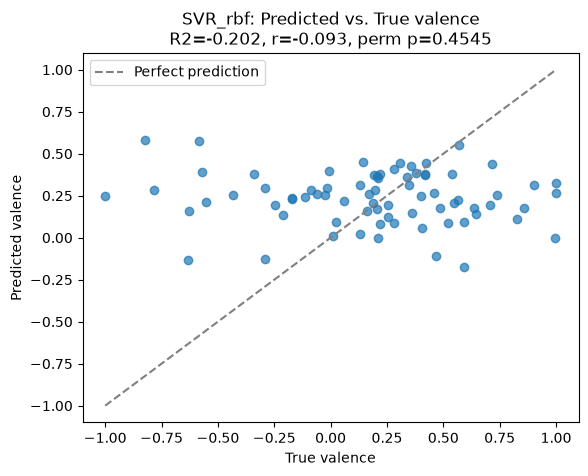

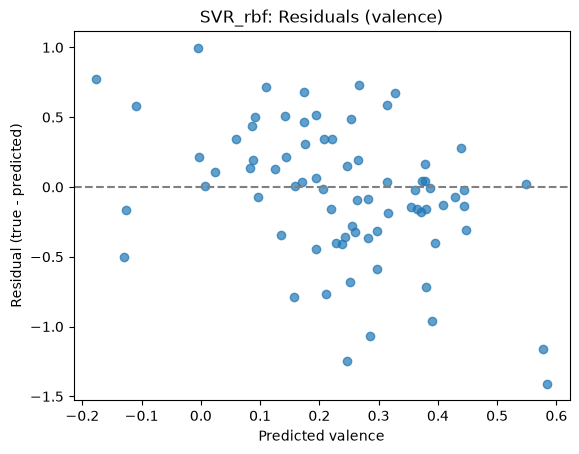


Dummy_mean (valence)
R2: -0.024
MAE: 0.349
Pearson r: -0.535 (p=0.0000)
Permutation p-value (R2): 1.0000


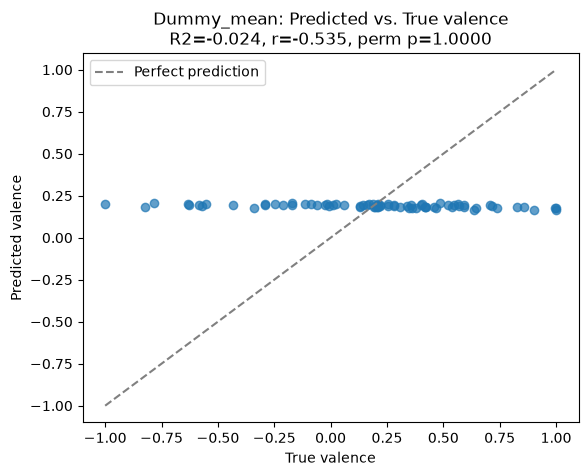

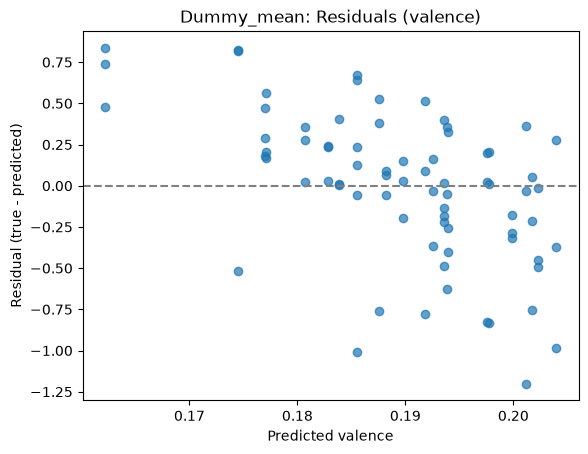


=== Regressor Comparison (valence) ===
    Regressor        R2       MAE  Pearson_r     Pearson_p  Permutation_p
6  Dummy_mean -0.024347  0.348755  -0.534979  7.629973e-07       1.000000
1       Lasso -0.037463  0.348369  -0.189725  1.030354e-01       0.344655
2  ElasticNet -0.075716  0.345581  -0.031424  7.889834e-01       0.325674
5     SVR_rbf -0.202444  0.368528  -0.092782  4.285203e-01       0.454545
3         PLS -0.411438  0.394501  -0.033416  7.759408e-01       0.355644
0       Ridge -2.139139  0.611170  -0.077186  5.104064e-01       0.545455
4  SVR_linear -2.371178  0.611286  -0.035801  7.604167e-01       0.151848

=== Feature Importance (Ridge, valence) ===
                      feature  importance_mean  importance_std
9          stroke_mean_length         0.052688        0.198154
8         stroke_total_length         0.051162        0.168504
10          stroke_std_length         0.029033        0.088505
46  speed_dominant_freq_power         0.027184        0.085715
43      

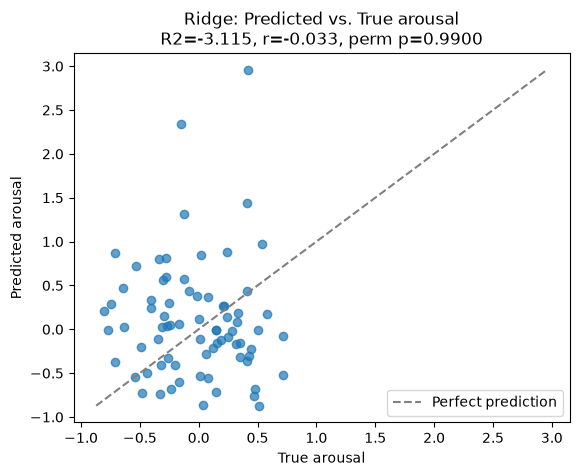

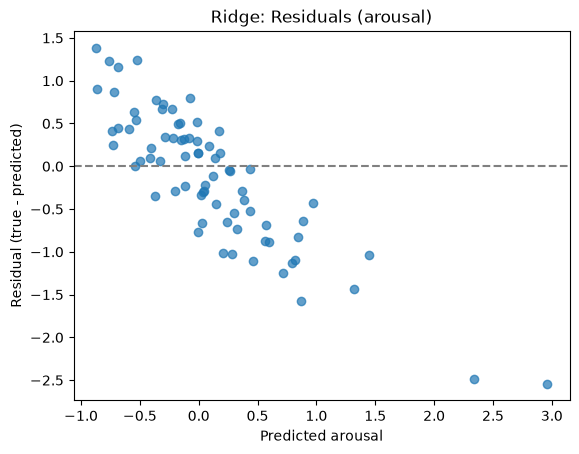


Lasso (arousal)
R2: -0.030
MAE: 0.338
Pearson r: -0.137 (p=0.2427)
Permutation p-value (R2): 0.9071


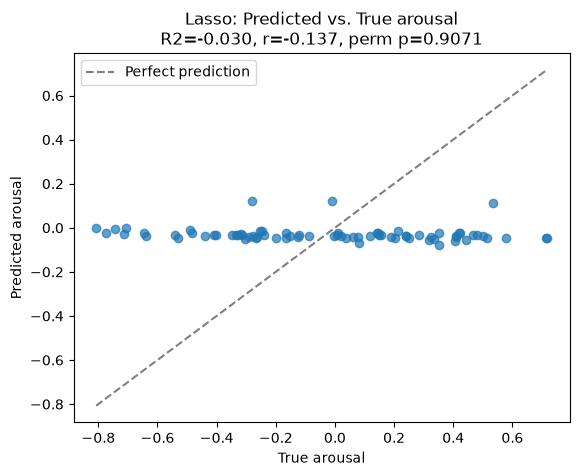

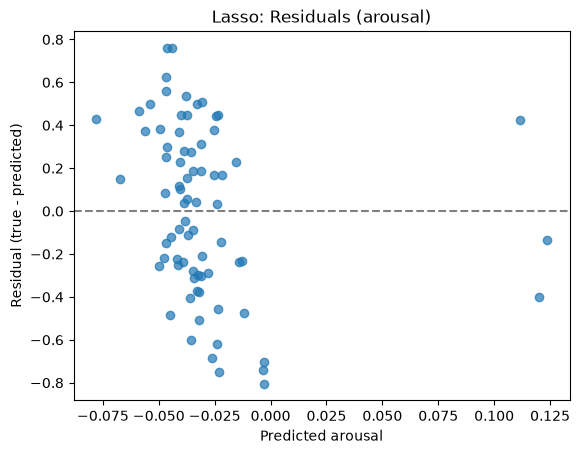


ElasticNet (arousal)
R2: -0.020
MAE: 0.332
Pearson r: 0.063 (p=0.5902)
Permutation p-value (R2): 0.7263


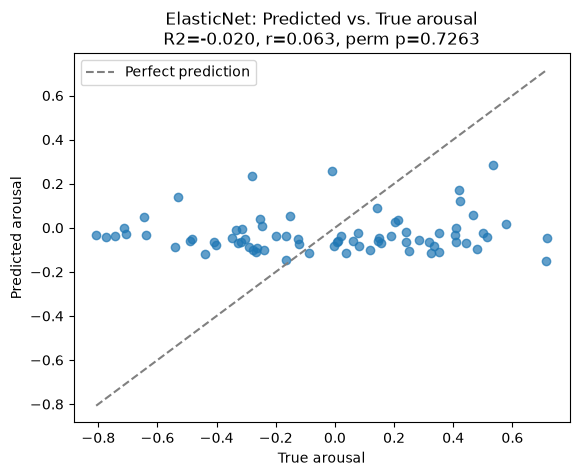

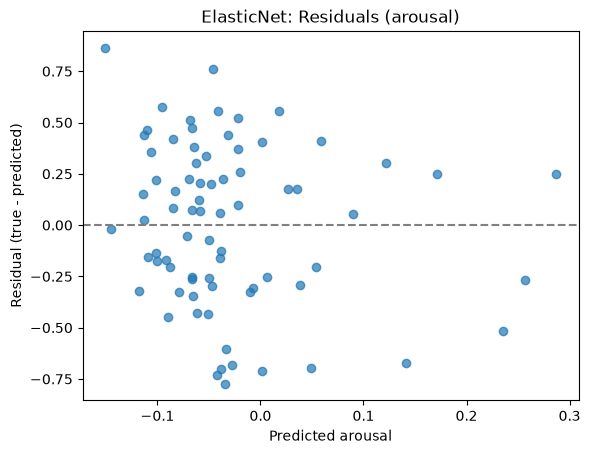


PLS (arousal)
R2: -0.785
MAE: 0.419
Pearson r: -0.085 (p=0.4704)
Permutation p-value (R2): 0.7822


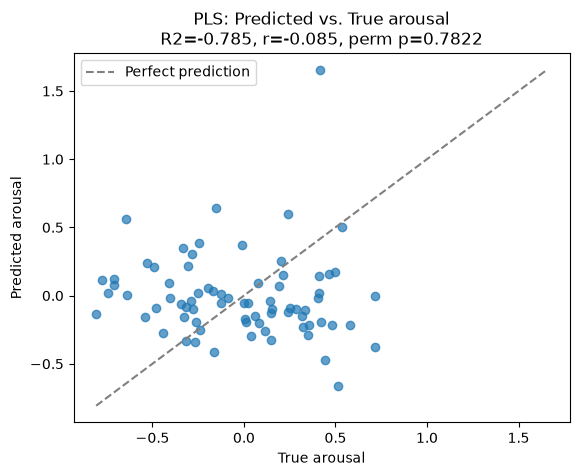

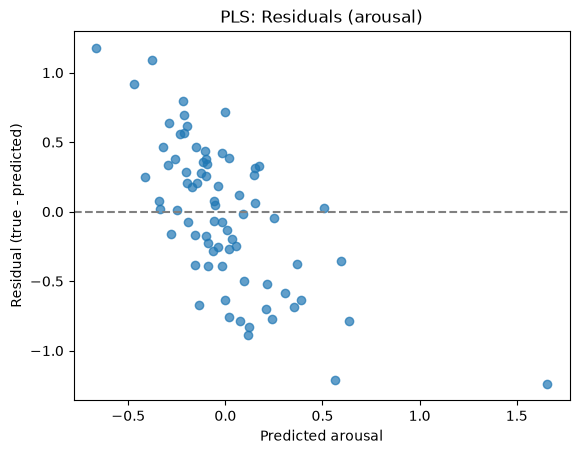


SVR_linear (arousal)
R2: -4.353
MAE: 0.676
Pearson r: 0.007 (p=0.9556)
Permutation p-value (R2): 0.9680


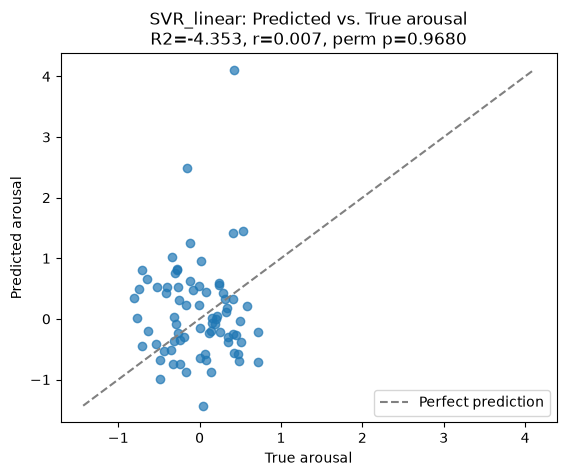

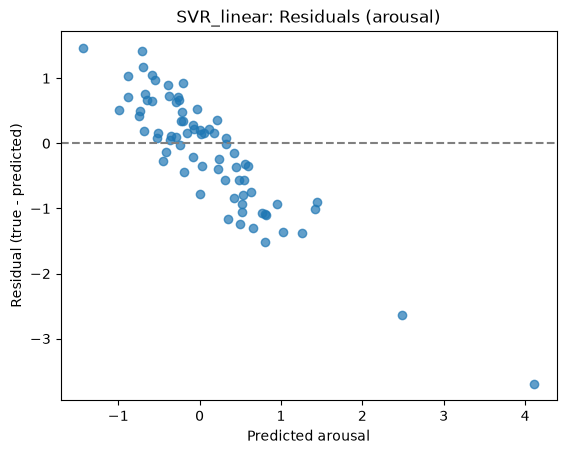


SVR_rbf (arousal)
R2: -0.317
MAE: 0.377
Pearson r: -0.276 (p=0.0165)
Permutation p-value (R2): 0.6953


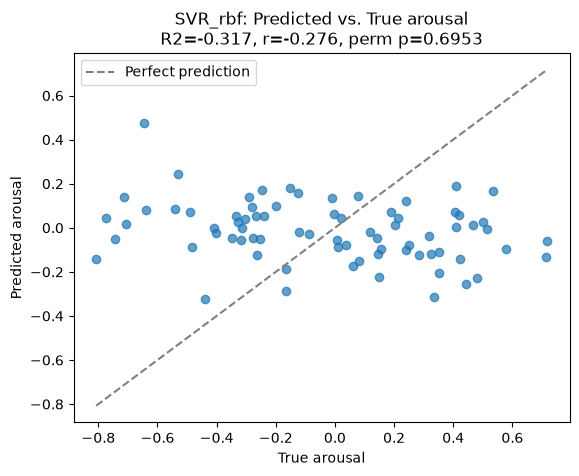

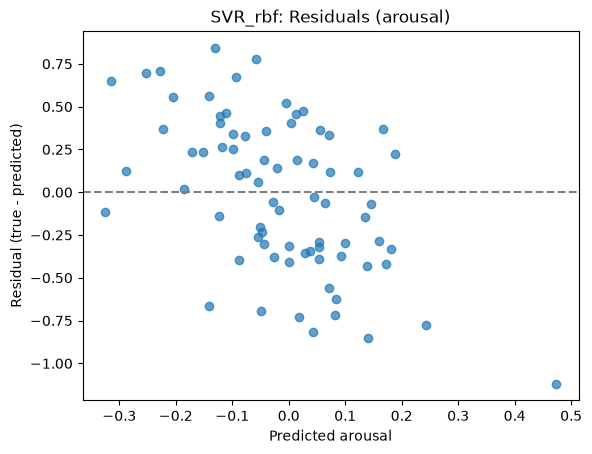


Dummy_mean (arousal)
R2: -0.038
MAE: 0.338
Pearson r: -0.672 (p=0.0000)
Permutation p-value (R2): 0.9441


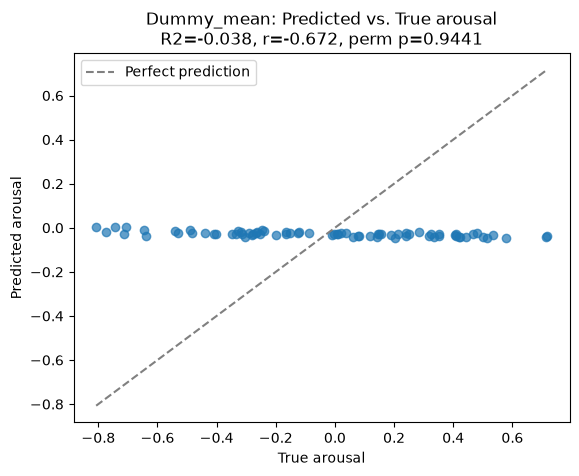

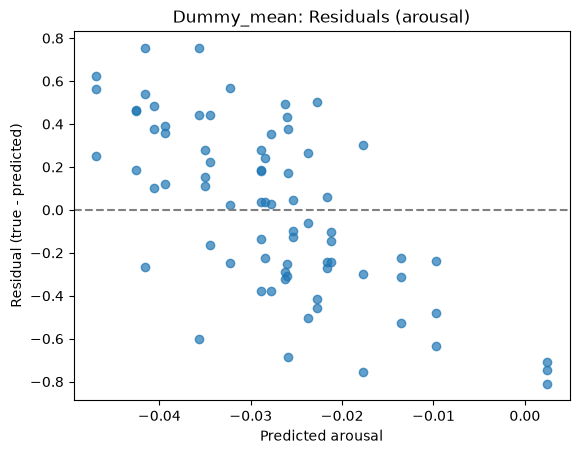


=== Regressor Comparison (arousal) ===
    Regressor        R2       MAE  Pearson_r     Pearson_p  Permutation_p
2  ElasticNet -0.020230  0.332188   0.063178  5.902415e-01       0.726274
1       Lasso -0.030470  0.337801  -0.136556  2.427130e-01       0.907093
6  Dummy_mean -0.038447  0.337508  -0.672273  3.993771e-11       0.944056
5     SVR_rbf -0.316916  0.376567  -0.275973  1.654820e-02       0.695305
3         PLS -0.785006  0.419387  -0.084626  4.703761e-01       0.782218
0       Ridge -3.115053  0.608832  -0.033384  7.761513e-01       0.990010
4  SVR_linear -4.353469  0.676106   0.006546  9.555527e-01       0.968032

=== Feature Importance (Ridge, arousal) ===
                     feature  importance_mean  importance_std
23  avg_time_between_strokes         0.041904        0.152374
37   stroke_std_straightness         0.037370        0.067243
10         stroke_std_length         0.022967        0.114245
35        tilt_pressure_corr         0.021699        0.058351
42           

In [10]:


def run_regression_analysis(X, y, groups, regressors, target_name):
    """
    Runs LOPO evaluation, permutation importance, and permutation testing
    for each regressor on a single continuous target (e.g. valence or arousal).
    """
    logo = LeaveOneGroupOut()
    results = []
    all_importances = {}

    for name, reg in regressors.items():
        pipeline = Pipeline([("scaler", StandardScaler()), ("clf", reg)])
        y_true, y_pred = [], []
        fold_importances = []

        for train_idx, test_idx in logo.split(X, y, groups):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            pipeline.fit(X_train, y_train)
            preds = pipeline.predict(X_test)

            y_true.extend(y_test)
            y_pred.extend(np.ravel(preds))

            # --- permutation importance on test fold ---
            # note: n_repeats=50 on a 1-sample LOPO test fold is degenerate
            # for r2 (undefined for n=1); use neg_mean_absolute_error instead,
            # which is well-defined per-sample.
            result = permutation_importance(
                pipeline,
                X_test,
                y_test,
                n_repeats=50,
                random_state=42,
                scoring="neg_mean_absolute_error"
            )
            fold_importances.append(result.importances_mean)

        fold_importances = np.array(fold_importances)
        all_importances[name] = fold_importances

        y_true = np.array(y_true)
        y_pred = np.array(y_pred)

        # Performance metrics (computed once, over all pooled LOPO predictions)
        r2 = r2_score(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r_pearson, p_pearson = pearsonr(y_true, y_pred)

        # Permutation test on the whole pipeline (this refits properly per permutation)
        score, perm_scores, pvalue = permutation_test_score(
            pipeline,
            X, y,
            groups=groups,
            cv=logo,
            scoring="r2",
            n_permutations=1000,
            n_jobs=-1
        )

        results.append({
            "Regressor": name,
            "R2": r2,
            "MAE": mae,
            "Pearson_r": r_pearson,
            "Pearson_p": p_pearson,
            "Permutation_p": pvalue
        })

        print(f"\n{name} ({target_name})")
        print(f"R2: {r2:.3f}")
        print(f"MAE: {mae:.3f}")
        print(f"Pearson r: {r_pearson:.3f} (p={p_pearson:.4f})")
        print(f"Permutation p-value (R2): {pvalue:.4f}")

        # --- Predicted vs actual scatter plot ---
        plt.figure()
        plt.scatter(y_true, y_pred, alpha=0.7)
        lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
        plt.plot(lims, lims, linestyle="--", color="gray", label="Perfect prediction")
        plt.xlabel(f"True {target_name}")
        plt.ylabel(f"Predicted {target_name}")
        plt.title(f"{name}: Predicted vs. True {target_name}\nR2={r2:.3f}, r={r_pearson:.3f}, perm p={pvalue:.4f}")
        plt.legend()
        fig_name_scatter = f"figures/scatter_{name}_{target_name}_300_dpi.png"
        plt.savefig(fig_name_scatter, dpi=300, bbox_inches="tight")
        plt.show()

        # --- Residual plot ---
        residuals = y_true - y_pred
        plt.figure()
        plt.scatter(y_pred, residuals, alpha=0.7)
        plt.axhline(0, linestyle="--", color="gray")
        plt.xlabel(f"Predicted {target_name}")
        plt.ylabel("Residual (true - predicted)")
        plt.title(f"{name}: Residuals ({target_name})")
        fig_name_resid = f"figures/residuals_{name}_{target_name}_300_dpi.png"
        plt.savefig(fig_name_resid, dpi=300, bbox_inches="tight")
        plt.show()

    # Summary table
    results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
    print(f"\n=== Regressor Comparison ({target_name}) ===")
    print(results_df)

    # Feature importance tables
    importance_tables = {}
    for name in regressors.keys():
        importances = all_importances[name]
        importance_df = pd.DataFrame({
            "feature": X.columns,
            "importance_mean": importances.mean(axis=0),
            "importance_std": importances.std(axis=0)
        }).sort_values("importance_mean", ascending=False)
        importance_tables[name] = importance_df
        print(f"\n=== Feature Importance ({name}, {target_name}) ===")
        print(importance_df.head(10))

    return results_df, importance_tables

# Run separately for valence and arousal
results_valence, importances_valence = run_regression_analysis(
    X, y_valence, groups, regressors, target_name="valence"
)
results_arousal, importances_arousal = run_regression_analysis(
    X, y_arousal, groups, regressors, target_name="arousal"
)